In [1]:
# init
import importlib, sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis

from IPython import get_ipython

from tqdm import tqdm

Textwidth: float = 4.25279  # in
Textheight: float = 6.85173  # in

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic("config", "InlineBackend.rc = {'figure.dpi': 600}")

from superconductivity.style.thesislayout import save_figure
from superconductivity.utilities.functions.fill_nans import fill
from superconductivity.utilities.functions.upsampling import upsample

from nptdms import TdmsFile

In [3]:
# get data single-iv tb
file = "/Users/oliver/Documents/measurement data/SSET/22 02b Scheer2/36_9 - unbroken/SCGateMap.tdms"
key = "2022-02-17 20:45:50 G3.60mV"
nu_sample_Hz, amp, rref = 5000.0, (2000.0, 500.0), 102000.0
dt_sample_s = 0.00019999999999999998
nu_downsample_Hz = 43.0
dt_downsample_s = 1 / nu_downsample_Hz

sweep = (25_000, 75_000)

Vbias0_mV = np.linspace(-0.7, 0.7, 3501)

with TdmsFile.open(file) as f:
    sample_V = f[key]["Sample"].as_dataframe()
    reference_V = f[key]["Reference"].as_dataframe()
    sample_V = sample_V.values
    reference_V = reference_V.values

sample_V = sample_V[sweep[0] : sweep[1], 0]
reference_V = reference_V[sweep[0] : sweep[1], 0]
time_s = np.arange(len(sample_V)) * dt_sample_s

nu_time_s = np.arange(0, np.max(time_s), dt_downsample_s)
nu_sample_V = sc.bin_y_over_x(sample_V, time_s, nu_time_s)
nu_reference_V = sc.bin_y_over_x(reference_V, time_s, nu_time_s)

v_mV = nu_sample_V * 1e3 / amp[0]
i_nA = nu_reference_V * 1e9 / (amp[1] * rref)
valid = np.logical_and(np.isfinite(v_mV), np.isfinite(i_nA))
i_nA, v_mV = upsample(i_nA[valid]), upsample(v_mV[valid])
I0_nA = sc.bin_y_over_x(i_nA, v_mV, Vbias0_mV)

In [4]:
# fit single-iv tb

from scipy.optimize import curve_fit

GN_G0 = 0.7694245093456741
T_K = 0.0
Delta_meV = 0.19
gamma_meV = 1e-9
sigmaV_mV = 0.00

valid = np.isfinite(I0_nA)
Vbias0_mV = Vbias0_mV[valid]
I0_nA = I0_nA[valid]


from superconductivity.models.basics.noise import evaluate_with_voltage_noise
from superconductivity.models.bcs.backend import E0_meV
from superconductivity.models.bcs.backend.np import convolution_np
from superconductivity.utilities.constants import G0_muS


def sntb(V_mV, Delta_meV, T_K, GN_G0):
    V_mV = np.asarray(V_mV, dtype=float)

    def current(V):
        return (
            convolution_np(
                V,
                E0_meV,
                T_K,
                T_K,
                0.0,  # normal electrode
                Delta_meV,  # superconducting electrode
                0.0,
                1e-6,
            )
            * GN_G0
            * G0_muS
        )

    if sigmaV_mV > 0:
        return evaluate_with_voltage_noise(
            V_mV,
            current,
            sigmaV_mV,
            order=64,
        )
    else:
        return current(V_mV)


popt, pcov = curve_fit(
    sntb,
    Vbias0_mV,
    I0_nA,
    p0=(0.19737718, 0.04246827, 0.79868269),
    bounds=((0.18, 0.001, 0.6), (0.23, 1.2, 0.8)),
    maxfev=10_000,
)
Ifit0_nA = sntb(Vbias0_mV, *popt)
Delta_meV, T_K, GN_G0 = popt
Iexp0 = I0_nA / (Delta_meV * GN_G0 * sc.G0_muS)
Ifit0 = Ifit0_nA / (Delta_meV * GN_G0 * sc.G0_muS)
Vbias0 = Vbias0_mV / Delta_meV

Vbias = np.linspace(-0.5, 2.5, 301)
Iexp = sc.bin_y_over_x(upsample(Iexp0), upsample(Vbias0), Vbias)
Vexp = sc.bin_y_over_x(upsample(Vbias0), upsample(Iexp0), Vbias)
dGexp = np.gradient(Iexp, Vbias, axis=-1)
dRexp = np.gradient(Vexp, Vbias, axis=-1)

Ifit = sc.bin_y_over_x(upsample(Ifit0), upsample(Vbias0), Vbias)
Vfit = sc.bin_y_over_x(upsample(Vbias0), upsample(Ifit0), Vbias)
dGfit = np.gradient(Ifit, Vbias, axis=-1)
dRfit = np.gradient(Vfit, Vbias, axis=-1)
Delta_meV

np.float64(0.19751030557218935)

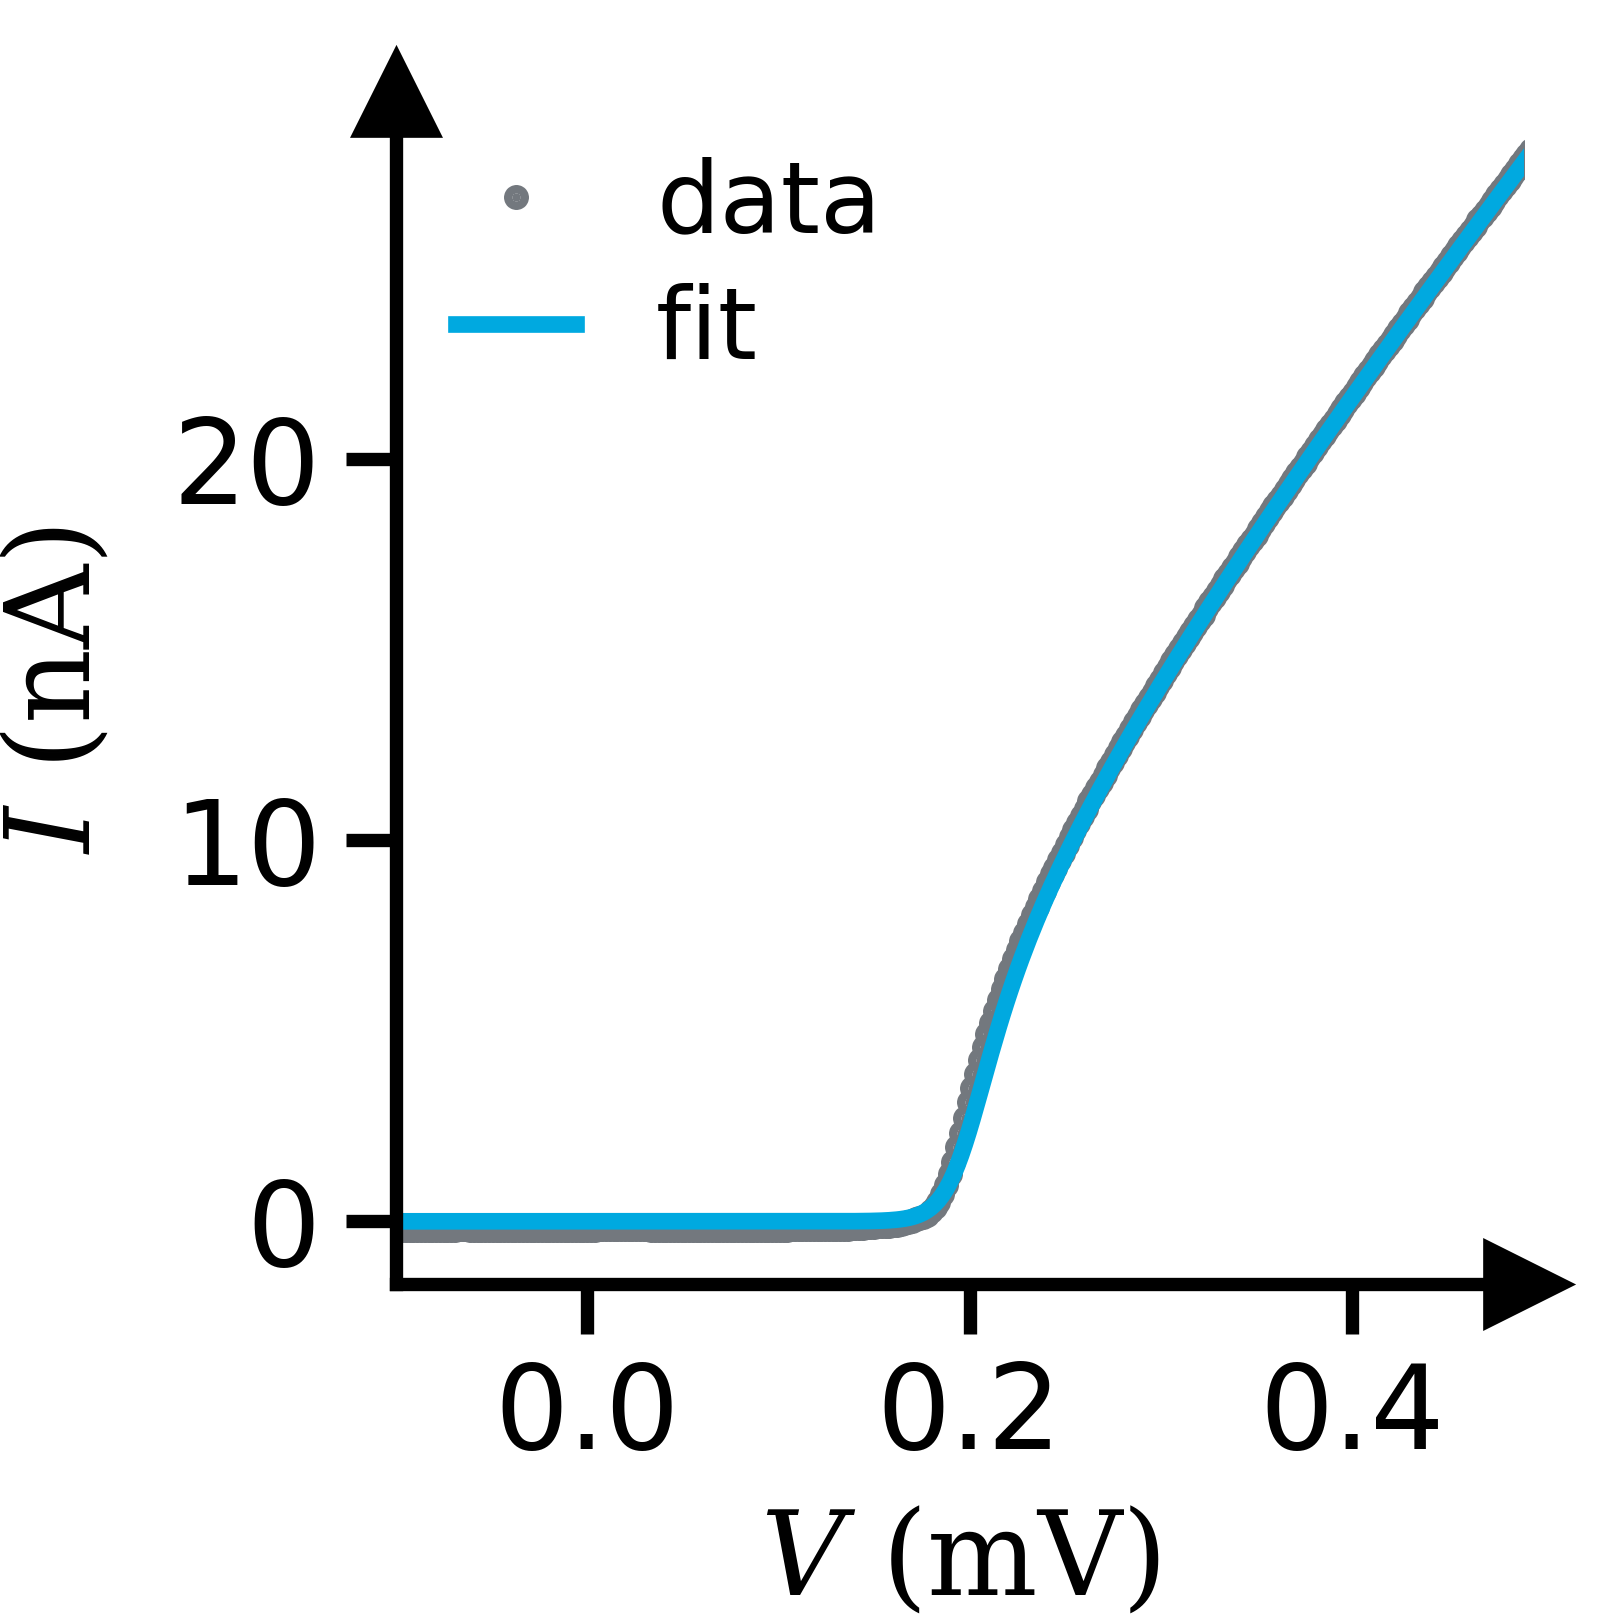

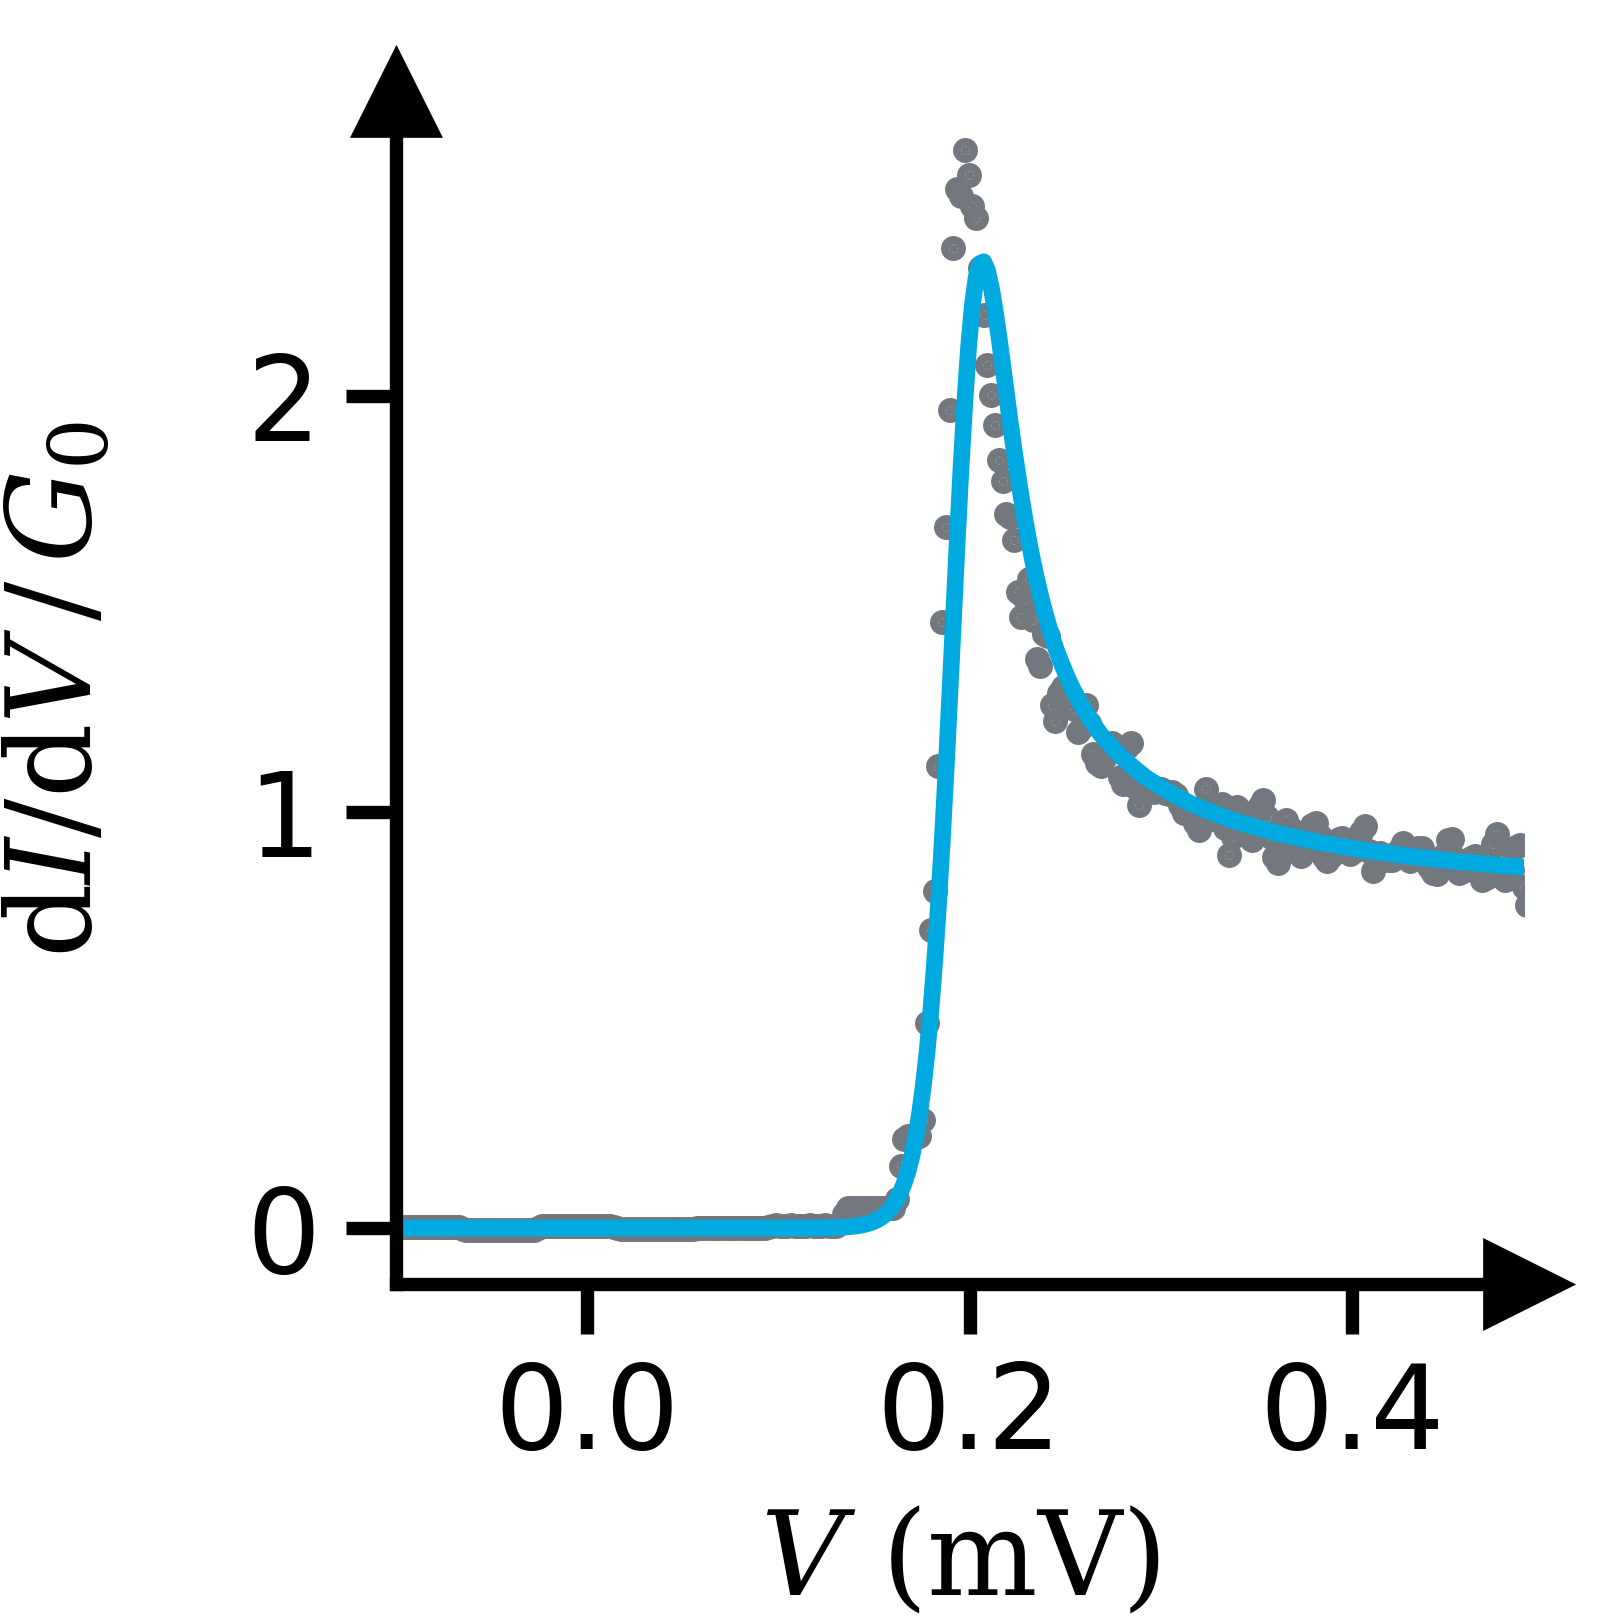

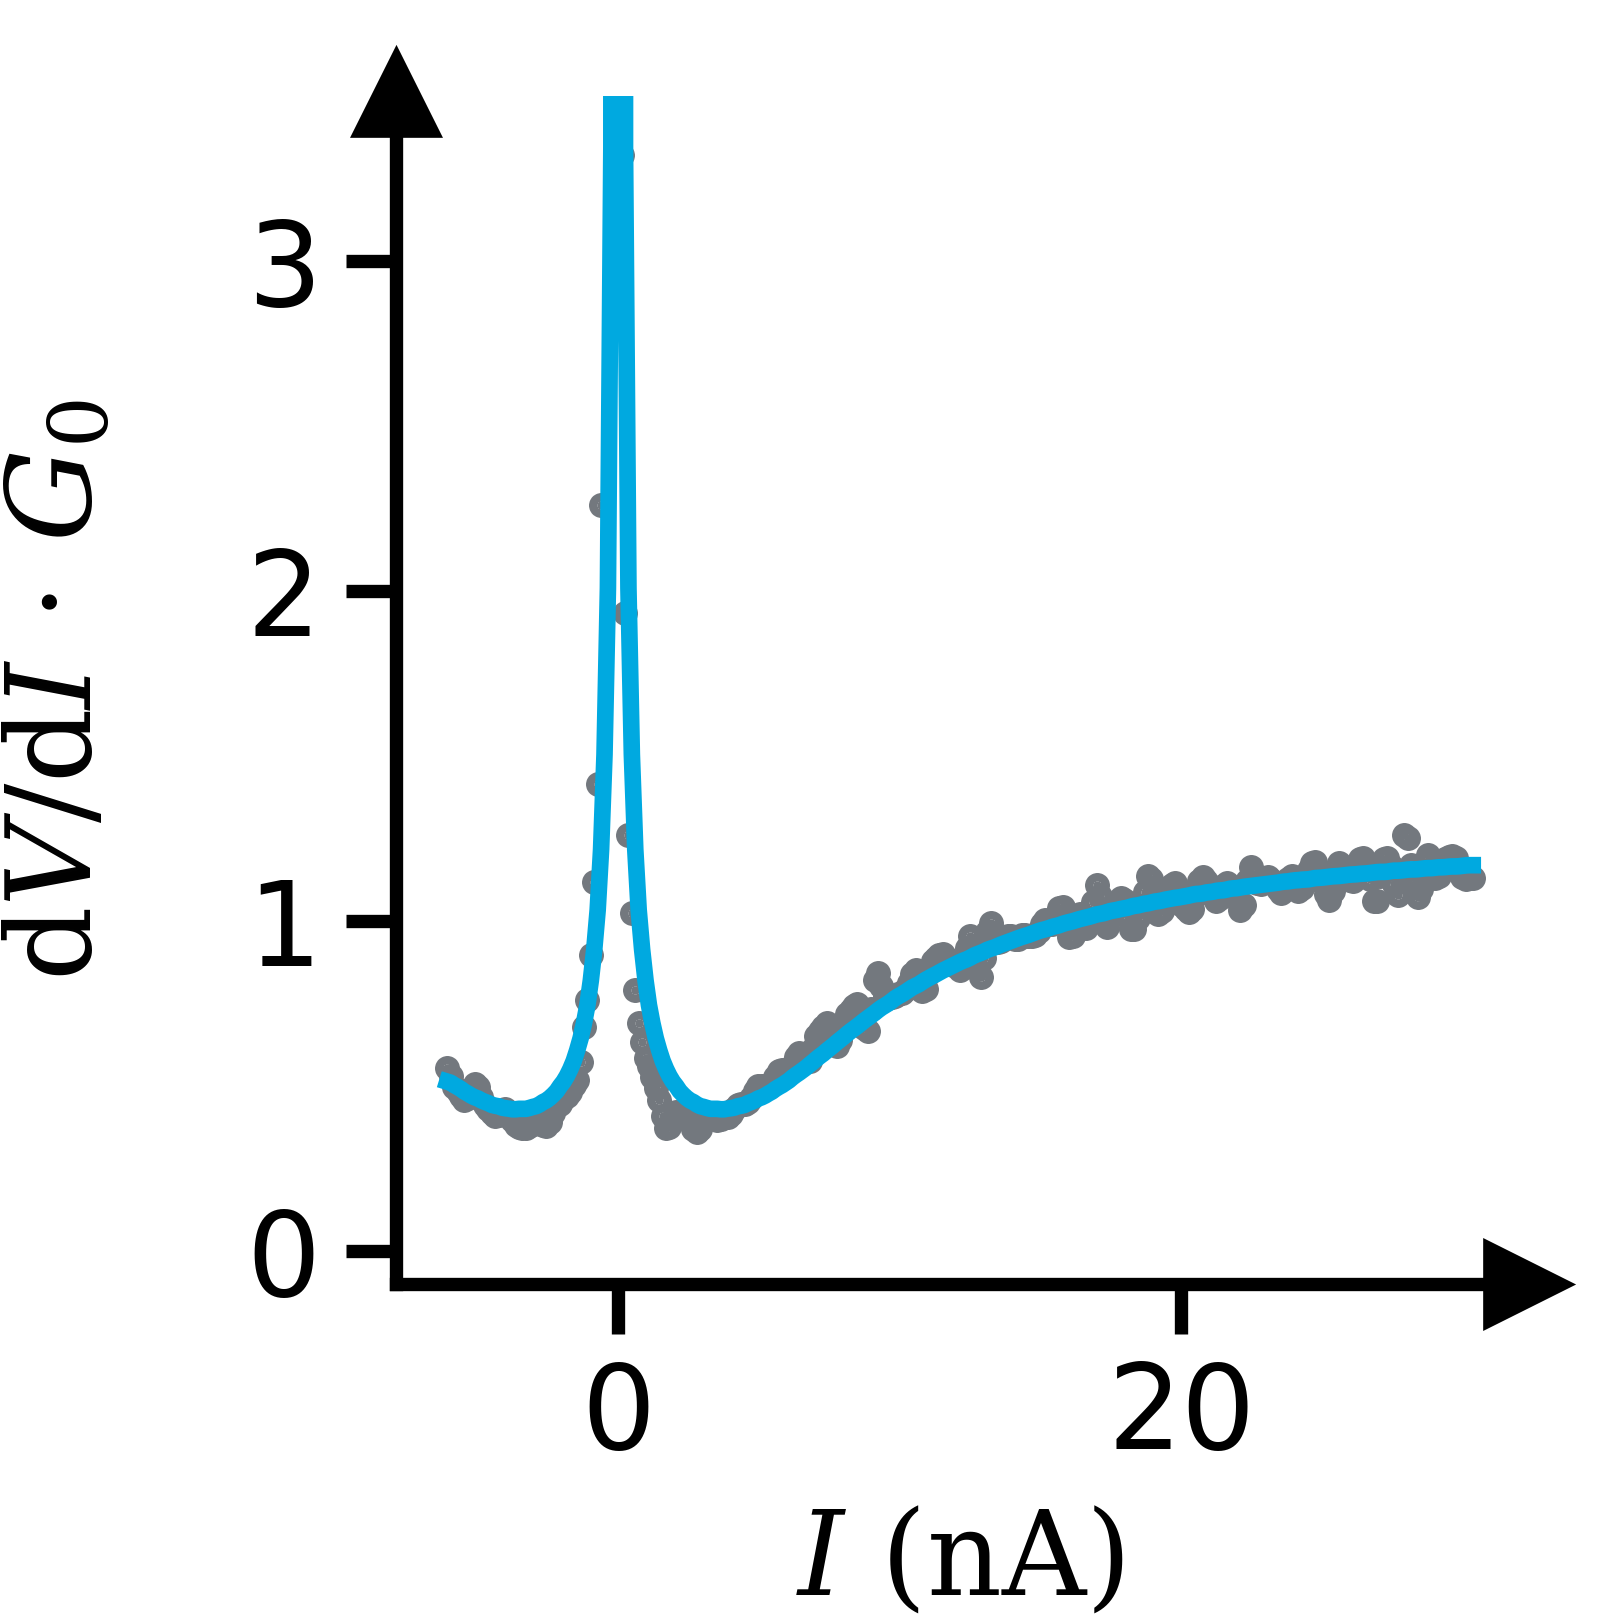

In [5]:
# plot single-iv tb

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Vbias * Delta_meV,
    Iexp * Delta_meV * GN_G0 * sc.G0_muS,
    ".",
    color=sc.seegrau100,
    ms=1.0,
    label="data",
    zorder=-1,
)
ax.plot(
    Vbias * Delta_meV,
    Ifit * Delta_meV * GN_G0 * sc.G0_muS,
    "-",
    color=sc.seeblau100,
    label="fit",
    zorder=0,
)
# ax.set_yticks([0, 20, 40, 60])
# ax.set_ylim(None, 75)
# ax.set_xticks([0, 0.2, 0.4])
ax.set_xlim(-0.1, 0.49)

ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/tb-single/iv",
    "$V\\ \\mathrm{(mV)}$",
    "$I\\ \\mathrm{(nA)}$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(Vbias * Delta_meV, dGexp * GN_G0, ".", color=sc.seegrau100, ms=1.0)
ax.plot(Vbias * Delta_meV, dGfit * GN_G0, "-", color=sc.seeblau100)
ax.set_xticks([0, 0.2, 0.4])
ax.set_xlim(-0.1, 0.49)
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/tb-single/didv",
    "$V\\ \\mathrm{(mV)}$",
    "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_0$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Vbias * Delta_meV * GN_G0 * sc.G0_muS,
    dRexp / GN_G0,
    ".",
    color=sc.seegrau100,
    ms=1.0,
)
ax.plot(Vbias * Delta_meV * GN_G0 * sc.G0_muS, dRfit / GN_G0, "-", color=sc.seeblau100)
ax.set_ylim(-0.1, 3.5)
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/tb-single/dvdi",
    "$I\\ \\mathrm{(nA)}$",
    "$\\mathrm{d}V/\\mathrm{d}I\\,\\cdot\\,G_0$",
)
plt.show()

In [6]:
# get data single-iv ssn set

file = "/Users/oliver/Documents/measurement data/SSET/22 02b Scheer2/65_6/SCMap.tdms"
# file = "/Users/oliver/Documents/measurement data/SSET/22 02b Scheer2/65_6/NCMap.tdms"
# file = "/Users/oliver/Documents/measurement data/SSET/22 03 Scheer2/36/SC_map.tdms"

nu_downsample_Hz = 137
sweep_up = (75_000, 125_000)
sweep_down = (24000, 70000)

keys = []
values = []

with TdmsFile.open(file) as f:
    mkeys = f.groups()
    for mkey in mkeys:
        name = mkey.name
        if name not in ["ZeroOffsetAdjust", "Thermometry", "Mapped"]:
            keys.append(name)
            value = name.split("G")[1].split("V")[0]
            if value[-1] == "m":
                value = float(value[:-1]) * 1e-3
            elif value[-1] == "u":
                value = float(value[:-1]) * 1e-6
            else:
                value = 0
            value = np.round(value, 6)
            values.append(value)

with TdmsFile.open(file) as f:
    amp = (
        f.properties["s_ampl_sample_effective_gain"],
        f.properties["s_ampl_reference_effective_gain"],
    )
    rref = f.properties["s_ampl_resistor"]
    nu_source_Hz = f.properties["s_source_f"]
    dt_sample_s = f[keys[0]].properties["s_dt"]
    nu_sample_Hz = 1 / dt_sample_s

Sample_up_V = []
Reference_up_V = []
Sample_down_V = []
Reference_down_V = []

dt_downsample_s = 1 / nu_downsample_Hz

with TdmsFile.open(file) as f:
    for i, key in enumerate(tqdm(keys)):
        if True:
            sample_V = f[key]["Sample"].as_dataframe()
            reference_V = f[key]["Reference"].as_dataframe()
            sample_V = sample_V.values
            reference_V = reference_V.values
            sweep = sweep_up
            sample_V = sample_V[sweep[0] : sweep[1], 0]
            reference_V = reference_V[sweep[0] : sweep[1], 0]
            time_s = np.arange(len(sample_V)) * dt_sample_s
            nu_time_s = np.arange(0, np.max(time_s), dt_downsample_s)
            nu_sample_V = sc.bin_y_over_x((sample_V), (time_s), nu_time_s)
            nu_reference_V = sc.bin_y_over_x((reference_V), (time_s), nu_time_s)

            Sample_up_V.append(nu_sample_V)
            Reference_up_V.append(nu_reference_V)

            sample_V = f[key]["Sample"].as_dataframe()
            reference_V = f[key]["Reference"].as_dataframe()
            sample_V = sample_V.values
            reference_V = reference_V.values

            sweep = sweep_down
            sample_V = sample_V[sweep[0] : sweep[1], 0]
            reference_V = reference_V[sweep[0] : sweep[1], 0]
            time_s = np.arange(len(sample_V)) * dt_sample_s
            nu_time_s = np.arange(0, np.max(time_s), dt_downsample_s)
            nu_sample_V = sc.bin_y_over_x((sample_V), (time_s), nu_time_s)
            nu_reference_V = sc.bin_y_over_x((reference_V), (time_s), nu_time_s)

            Sample_down_V.append(nu_sample_V)
            Reference_down_V.append(nu_reference_V)

Vbias_mV = np.linspace(-1.2, 1.2, 301)
Ibias_nA = np.linspace(-18, 18, 301)
Vgate_mV = np.array(values, dtype=np.float64) * 1e3

Iup_nA = np.zeros((Vgate_mV.shape[0], Vbias_mV.shape[0]))
Vup_mV = np.zeros((Vgate_mV.shape[0], Ibias_nA.shape[0]))
Idown_nA = np.zeros((Vgate_mV.shape[0], Vbias_mV.shape[0]))
Vdown_mV = np.zeros((Vgate_mV.shape[0], Ibias_nA.shape[0]))

for i, key in enumerate(tqdm(keys)):
    vup_mV = Sample_up_V[i] * 1e3 / amp[0]
    iup_nA = Reference_up_V[i] * 1e9 / (amp[1] * rref)
    vdown_mV = Sample_down_V[i] * 1e3 / amp[0]
    idown_nA = Reference_down_V[i] * 1e9 / (amp[1] * rref)

    valid = np.logical_and(np.isfinite(vup_mV), np.isfinite(iup_nA))
    iup_nA, vup_mV = upsample(iup_nA[valid]), upsample(vup_mV[valid])
    # iup_nA, vup_mV = (iup_nA[valid]), (vup_mV[valid])
    Iup_nA[i, :] = sc.bin_y_over_x(iup_nA, vup_mV, Vbias_mV)
    Vup_mV[i, :] = sc.bin_y_over_x(vup_mV, iup_nA, Ibias_nA)

    valid = np.logical_and(np.isfinite(vdown_mV), np.isfinite(idown_nA))
    idown_nA, vdown_mV = upsample(idown_nA[valid]), upsample(vdown_mV[valid])
    # idown_nA, vdown_mV = (idown_nA[valid]), (vdown_mV[valid])
    Idown_nA[i, :] = sc.bin_y_over_x(idown_nA, vdown_mV, Vbias_mV)
    Vdown_mV[i, :] = sc.bin_y_over_x(vdown_mV, idown_nA, Ibias_nA)

100%|██████████| 81/81 [00:04<00:00, 19.34it/s]


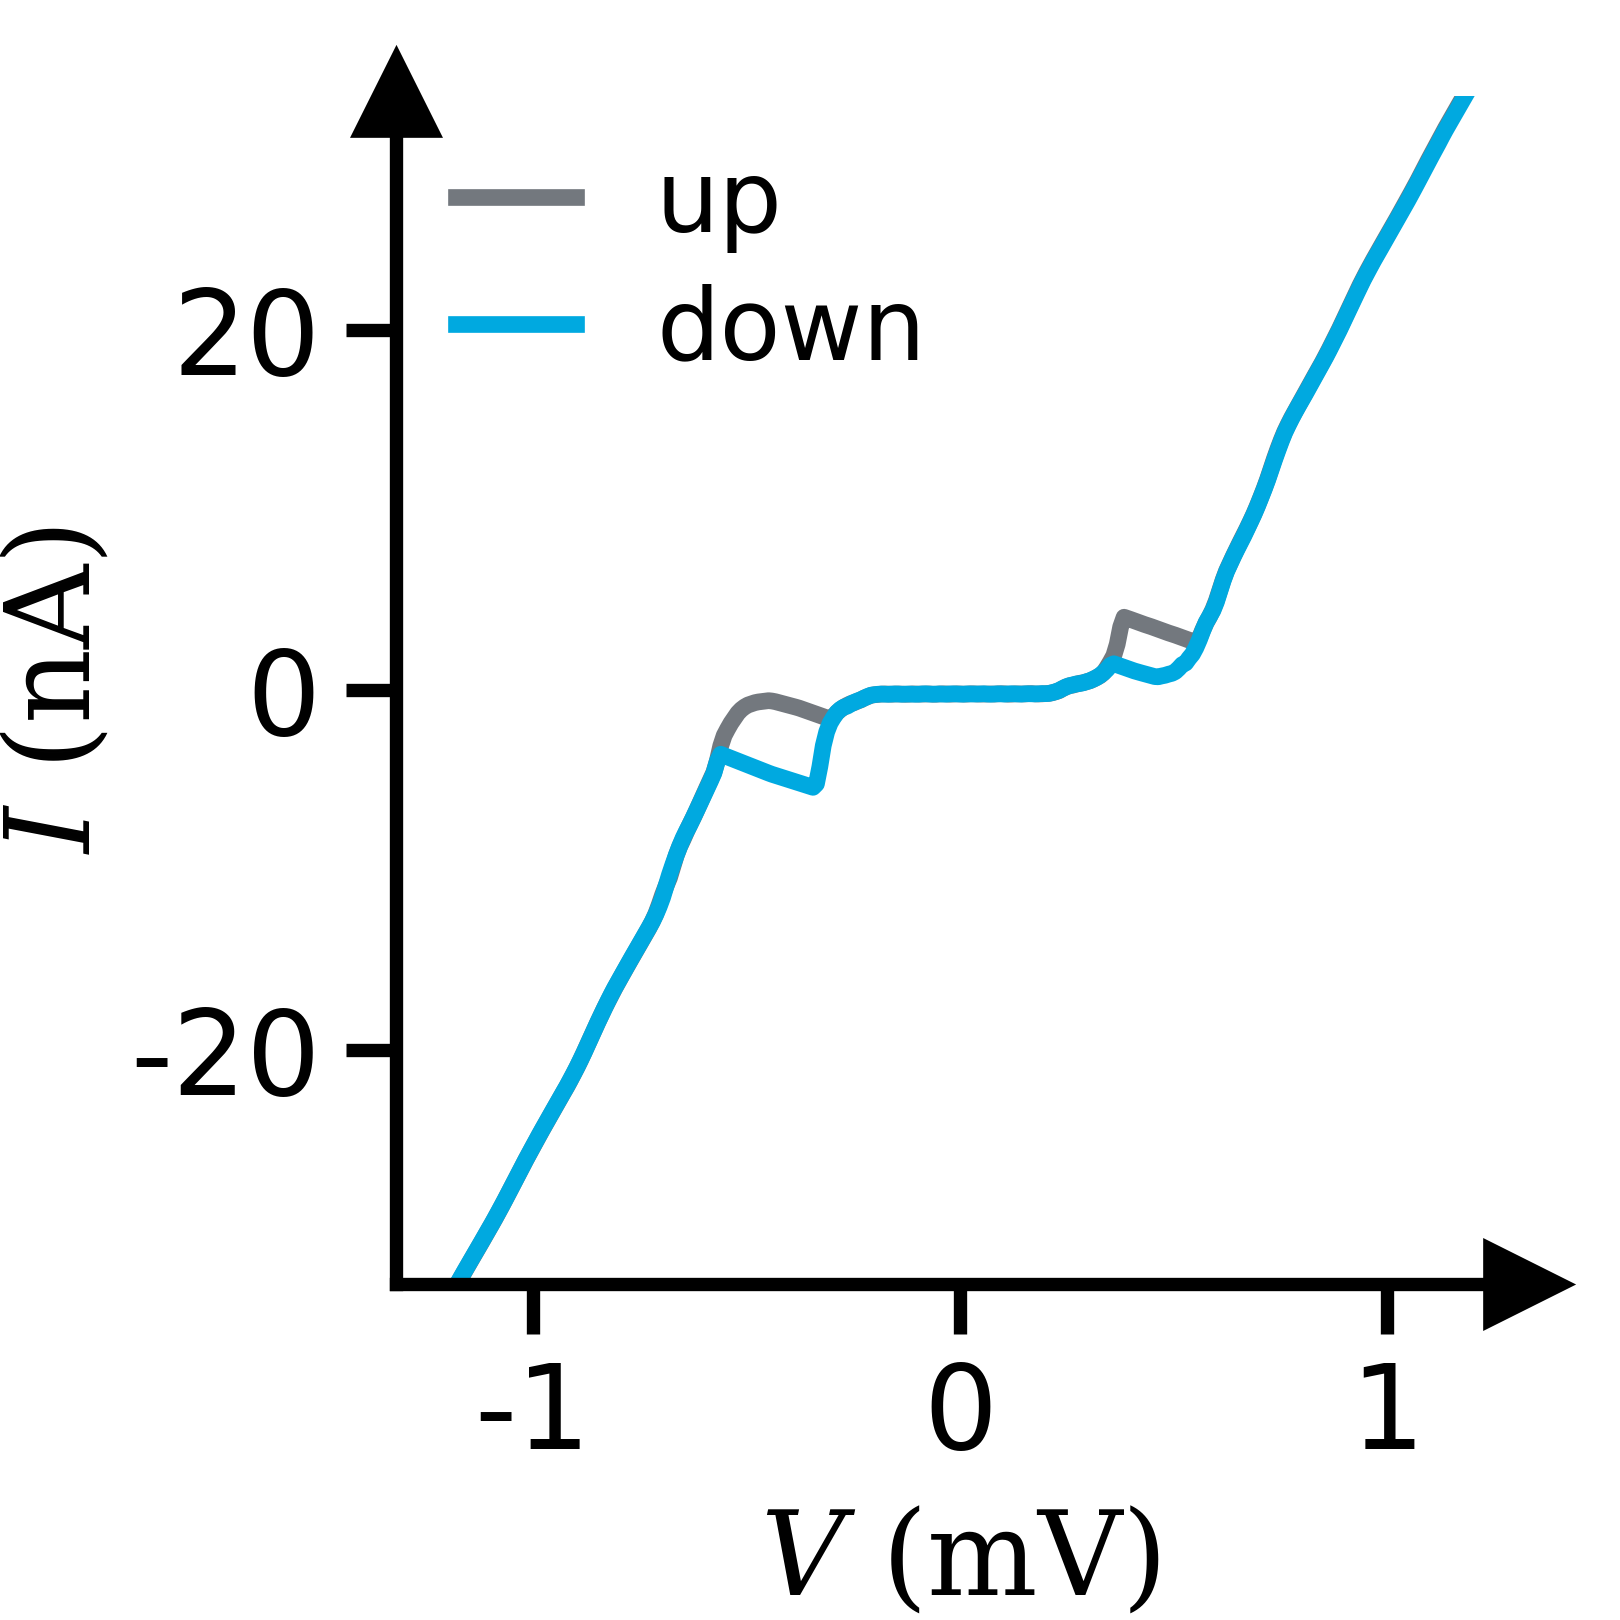

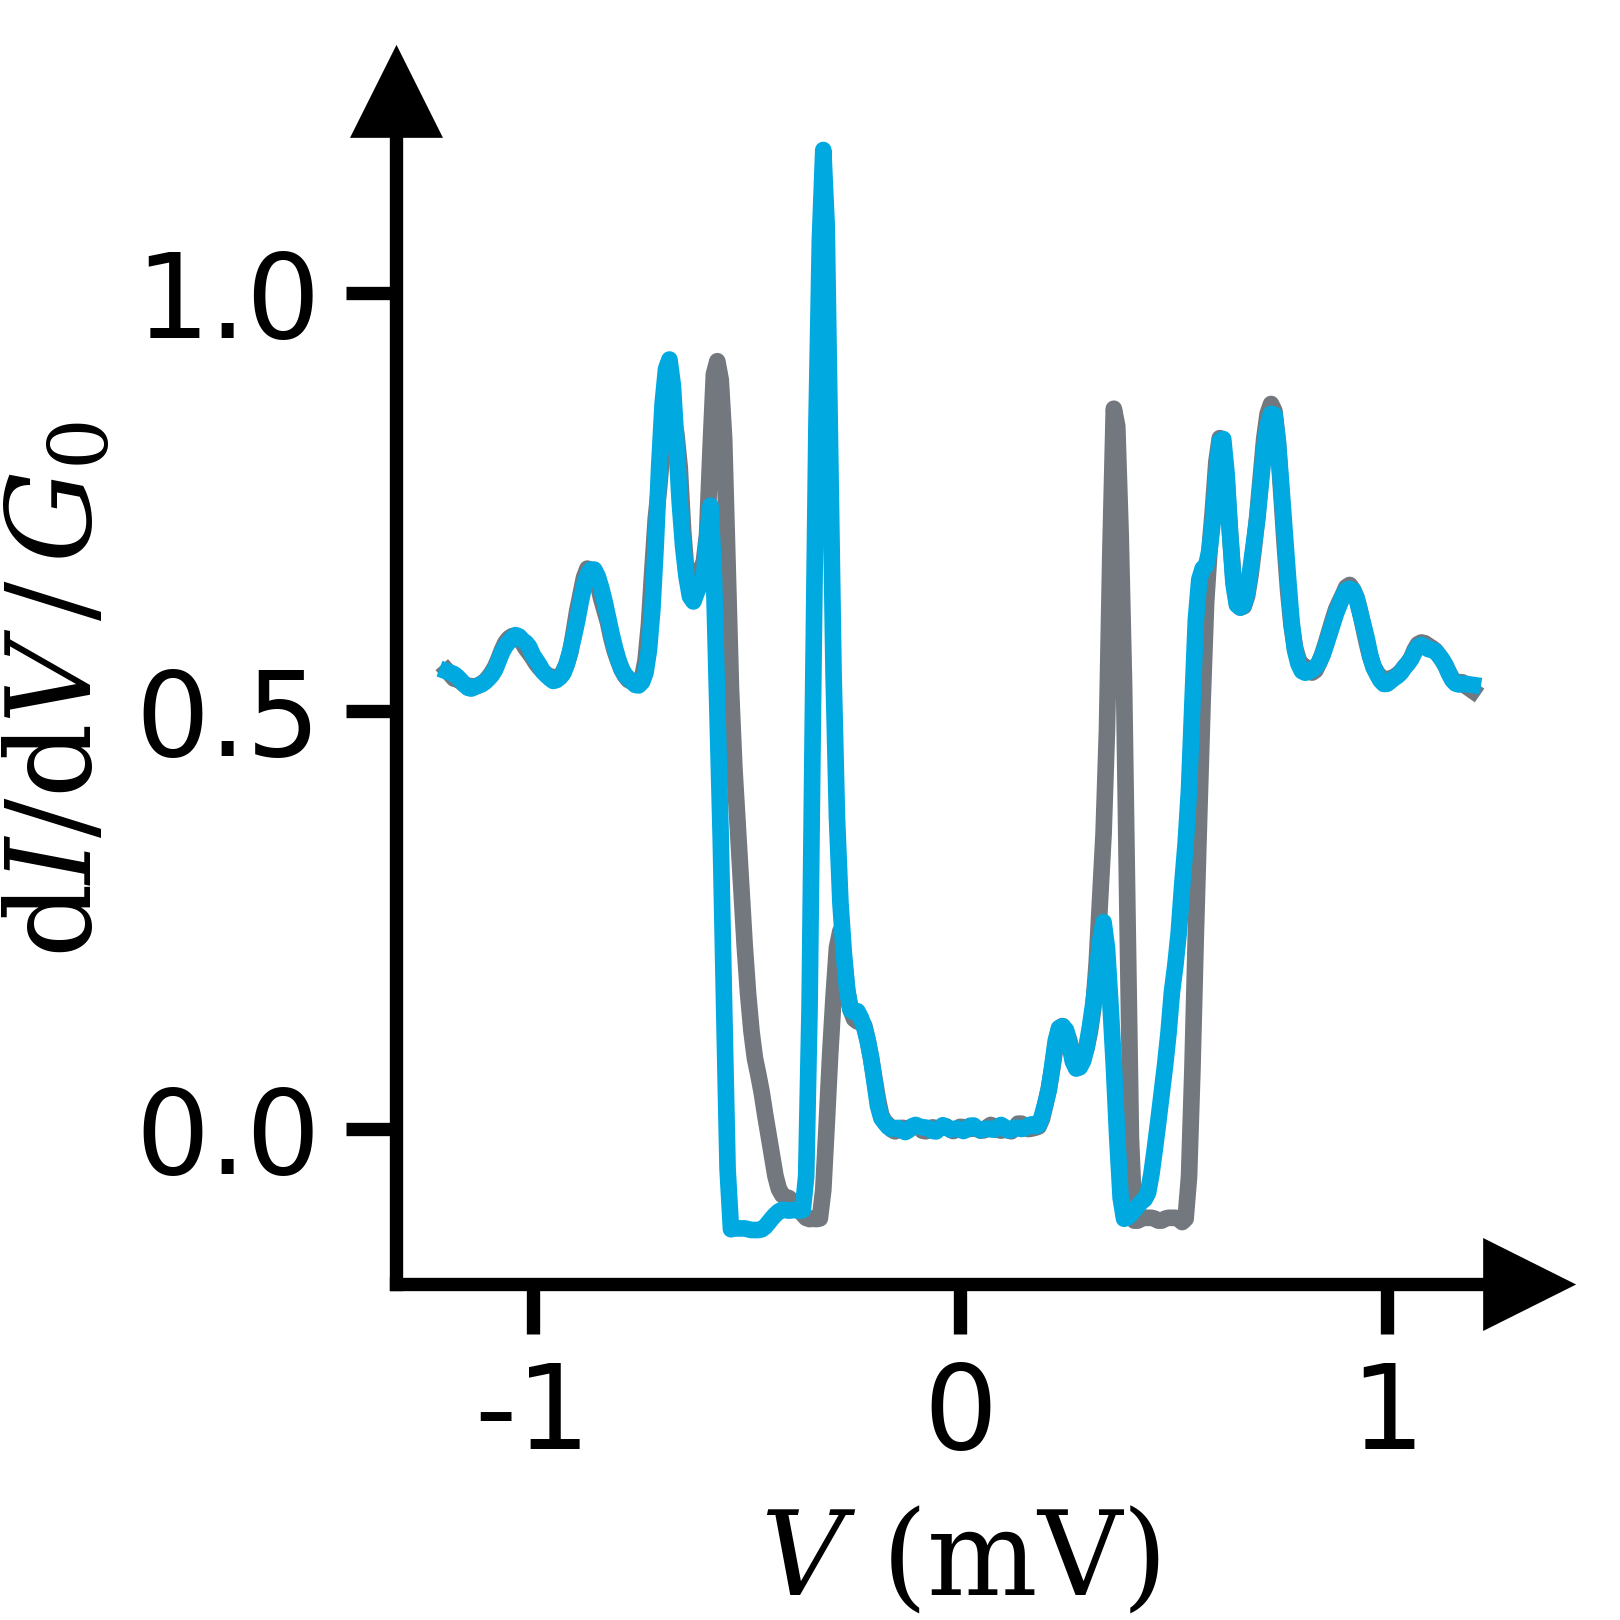

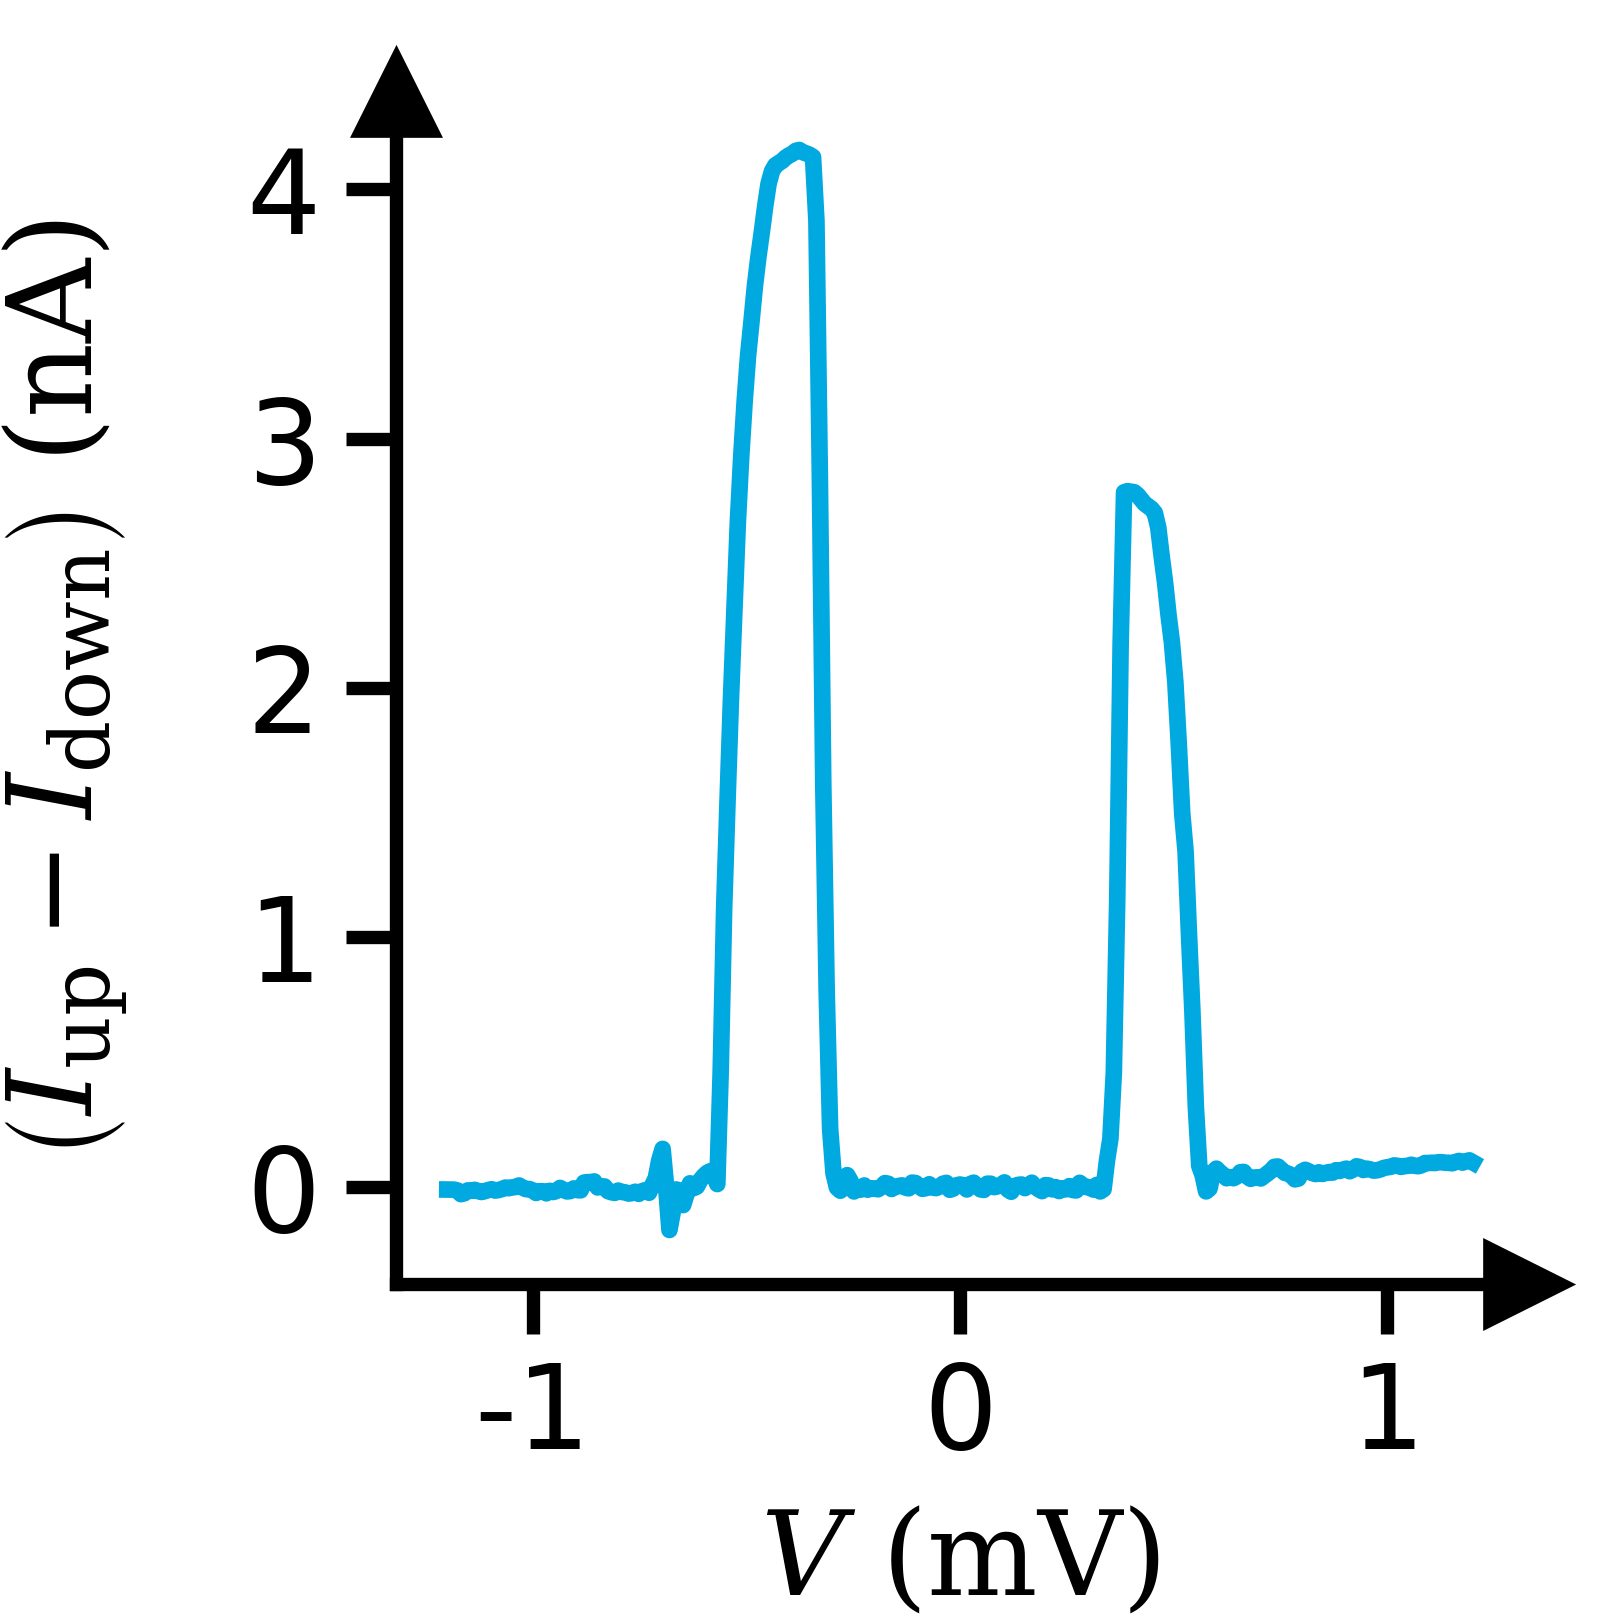

In [7]:
# plot single-iv cs
index = 21
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    # Sample_up_V[index] * 1e3 / amp[0],
    # Reference_up_V[index] * 1e9 / (amp[1] * rref),
    Vbias_mV,
    Iup_nA[index, :],
    "-",
    color=sc.seegrau100,
    ms=1.0,
    label="up",
    zorder=-1,
)
ax.plot(
    # Sample_down_V[index] * 1e3 / amp[0],
    # Reference_down_V[index] * 1e9 / (amp[1] * rref),
    Vbias_mV,
    Idown_nA[index, :],
    "-",
    color=sc.seeblau100,
    label="down",
    zorder=0,
)
# ax.set_yticks([0, 20, 40, 60])
ax.set_ylim(-33, 33)
# ax.set_xticks([0, 0.2, 0.4])
# ax.set_xlim(-1.1, 1.1)

ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/ssn-single/iv",
    "$V\\ \\mathrm{(mV)}$",
    "$I\\ \\mathrm{(nA)}$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Vbias_mV,
    savgol_filter(np.gradient(Iup_nA[index, :], Vbias_mV) / sc.G0_muS, 5, 1),
    "-",
    color=sc.seegrau100,
    ms=1.0,
)
ax.plot(
    Vbias_mV,
    savgol_filter(np.gradient(Idown_nA[index, :], Vbias_mV) / sc.G0_muS, 5, 1),
    "-",
    color=sc.seeblau100,
    ms=1.0,
)
# ax.set_ylim(-0.2, 1.7)
# ax.set_xlim(-1.1, 1.1)
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/ssn-single/didv",
    "$V\\ \\mathrm{(mV)}$",
    "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_0$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Vbias_mV,
    Iup_nA[index, :] - Idown_nA[index, :],
    "-",
    color=sc.seeblau100,
    ms=1.0,
)
# ax.set_ylim(-1, 30)
# ax.set_xlim(-1.1, 1.1)
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/ssn-single/dvdi",
    "$V\\ \\mathrm{(mV)}$",
    "$\\left(I_\\mathrm{up}-I_\\mathrm{down}\\right)\\ \\mathrm{(nA)}$",
)
plt.show()

In [8]:
# get midres data
Vbias_mV = np.linspace(-1.2, 1.2, 601)
Ibias_nA = np.linspace(-18, 18, 601)
Vgate_mV = np.array(values, dtype=np.float64) * 1e3

Iup_nA = np.zeros((Vgate_mV.shape[0], Vbias_mV.shape[0]))
Vup_mV = np.zeros((Vgate_mV.shape[0], Ibias_nA.shape[0]))
Idown_nA = np.zeros((Vgate_mV.shape[0], Vbias_mV.shape[0]))
Vdown_mV = np.zeros((Vgate_mV.shape[0], Ibias_nA.shape[0]))

for i, key in enumerate(tqdm(keys)):
    vup_mV = Sample_up_V[i] * 1e3 / amp[0]
    iup_nA = Reference_up_V[i] * 1e9 / (amp[1] * rref)
    vdown_mV = Sample_down_V[i] * 1e3 / amp[0]
    idown_nA = Reference_down_V[i] * 1e9 / (amp[1] * rref)

    valid = np.logical_and(np.isfinite(vup_mV), np.isfinite(iup_nA))
    iup_nA, vup_mV = upsample(iup_nA[valid]), upsample(vup_mV[valid])
    # iup_nA, vup_mV = (iup_nA[valid]), (vup_mV[valid])
    Iup_nA[i, :] = sc.bin_y_over_x(iup_nA, vup_mV, Vbias_mV)
    Vup_mV[i, :] = sc.bin_y_over_x(vup_mV, iup_nA, Ibias_nA)

    valid = np.logical_and(np.isfinite(vdown_mV), np.isfinite(idown_nA))
    idown_nA, vdown_mV = upsample(idown_nA[valid]), upsample(vdown_mV[valid])
    # idown_nA, vdown_mV = (idown_nA[valid]), (vdown_mV[valid])
    Idown_nA[i, :] = sc.bin_y_over_x(idown_nA, vdown_mV, Vbias_mV)
    Vdown_mV[i, :] = sc.bin_y_over_x(vdown_mV, idown_nA, Ibias_nA)

100%|██████████| 81/81 [00:04<00:00, 20.14it/s]


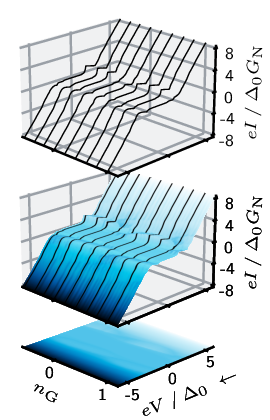

/Users/oliver/Documents/cryolab/dissertation-figures/ssn-set/sc-map/cal_iv/main.png

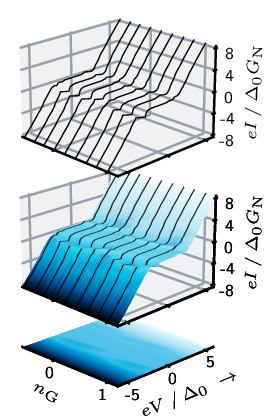

/Users/oliver/Documents/cryolab/dissertation-figures/ssn-set/sc-map/cal_didv/main.png

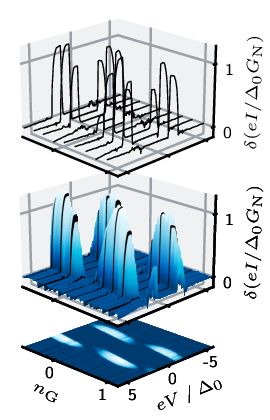

/Users/oliver/Documents/cryolab/dissertation-figures/ssn-set/sc-map/cal_dvdi/main.png

In [212]:
# ssn-set
dVgate_mV = 4.4
Cg_aF = 160.2 / dVgate_mV
GN_G0 = 0.533
Delta_meV = 0.19751030557218935
Vbias = Vbias_mV / Delta_meV
Vgate = Vgate_mV / dVgate_mV + 0.267
Iup = Iup_nA / (Delta_meV * GN_G0 * sc.G0_muS)
Idown = Idown_nA / (Delta_meV * GN_G0 * sc.G0_muS)
dGup = np.gradient(Iup, Vbias, axis=-1)
from superconductivity.visuals.landscape import export_landscape_thesis

exports = export_landscape_thesis(
    Vbias=Vbias,
    Abias=Vgate,
    Ibias=Vbias,
    Iexp=Iup,
    dGexp=dGup,
    dRexp=Iup - Idown,
    waterfall_traces=[-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1],
    name="cal",
    sub_dir=f"ssn-set/sc-map/",
    surface_points=(300, 100),
    plots=("iv",),
    Alabel="$n_\\mathrm{G}$",
    Vlabel="$eV\\,/\\,\\Delta_0\\ \\leftarrow$",
)
exports = export_landscape_thesis(
    Vbias=Vbias,
    Abias=Vgate,
    Ibias=Vbias,
    Iexp=Iup,
    dGexp=Idown,
    dRexp=Iup - Idown,
    waterfall_traces=[-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1],
    name="cal",
    sub_dir=f"ssn-set/sc-map/",
    surface_points=(300, 100),
    plots=("didv",),
    Alabel="$n_\\mathrm{G}$",
    Vlabel="$eV\\,/\\,\\Delta_0\\ \\rightarrow$",
    dGlabel="$eI\\,/\\,\\Delta_0G_\\mathrm{N}$",
)
exports = export_landscape_thesis(
    Vbias=Vbias,
    Abias=Vgate,
    Ibias=Vbias,
    Iexp=Iup,
    dGexp=dGup,
    dRexp=Iup - Idown,
    waterfall_traces=[-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1],
    name="cal",
    sub_dir=f"ssn-set/sc-map/",
    surface_points=(300, 100),
    Alabel="$n_\\mathrm{G}$",
    Ilabel="$eV\\,/\\,\\Delta_0$",
    dRlabel="$\\delta\\!\\left(eI/\\Delta_0G_\\mathrm{N}\\right)$",
    plots=("dvdi",),
)

In [9]:
# get highres data
Vbias_mV = np.linspace(-1.2, 1.2, 1201)
Ibias_nA = np.linspace(-18, 18, 1801)
Vgate_mV = np.array(values, dtype=np.float64) * 1e3

Iup_nA = np.zeros((Vgate_mV.shape[0], Vbias_mV.shape[0]))
Vup_mV = np.zeros((Vgate_mV.shape[0], Ibias_nA.shape[0]))
Idown_nA = np.zeros((Vgate_mV.shape[0], Vbias_mV.shape[0]))
Vdown_mV = np.zeros((Vgate_mV.shape[0], Ibias_nA.shape[0]))

for i, key in enumerate(tqdm(keys)):
    vup_mV = Sample_up_V[i] * 1e3 / amp[0]
    iup_nA = Reference_up_V[i] * 1e9 / (amp[1] * rref)
    vdown_mV = Sample_down_V[i] * 1e3 / amp[0]
    idown_nA = Reference_down_V[i] * 1e9 / (amp[1] * rref)

    valid = np.logical_and(np.isfinite(vup_mV), np.isfinite(iup_nA))
    iup_nA, vup_mV = upsample(iup_nA[valid]), upsample(vup_mV[valid])
    # iup_nA, vup_mV = (iup_nA[valid]), (vup_mV[valid])
    Iup_nA[i, :] = sc.bin_y_over_x(iup_nA, vup_mV, Vbias_mV)
    Vup_mV[i, :] = sc.bin_y_over_x(vup_mV, iup_nA, Ibias_nA)

    valid = np.logical_and(np.isfinite(vdown_mV), np.isfinite(idown_nA))
    idown_nA, vdown_mV = upsample(idown_nA[valid]), upsample(vdown_mV[valid])
    # idown_nA, vdown_mV = (idown_nA[valid]), (vdown_mV[valid])
    Idown_nA[i, :] = sc.bin_y_over_x(idown_nA, vdown_mV, Vbias_mV)
    Vdown_mV[i, :] = sc.bin_y_over_x(vdown_mV, idown_nA, Ibias_nA)

100%|██████████| 81/81 [00:04<00:00, 17.84it/s]


In [10]:
dGdiff = np.gradient(Iup - Idown, Vbias, axis=-1)

# region dIdV difference
fig, axes = sc.get_figures(
    figsize=(1.35, 1.5), padding=(0.3, 0.2, 0.0, 0.25), nrows=1, ncols=1
)
img = axes[0].pcolormesh(
    Vbias,
    Vgate,
    dGdiff,
    cmap="RdBu_r",
    clim=(-2.5, 2.5),
    rasterized=True,
)
for i, ax in enumerate(axes):
    # ax.set_ylim(0, 5.5)
    ax.set_xlim(-4, 4)

sc.daumenkino_layout(
    fig,
    axes,
    ylabel="$n_\\mathrm{G}$",
    xlabel="$eV\\,/\\,\\Delta_0$",
    xticks=[-2, 0, 2],
)

upper_edge = max(ax.get_position().y1 for ax in axes)
left = min(ax.get_position().x0 for ax in axes)
right = max(ax.get_position().x1 for ax in axes)

width = right - left
shrink = 0.5
new_width = width * shrink
new_left = left + 0.5 * (width - new_width)
new_left = left + (width - new_width)

cax = fig.add_axes([new_left, upper_edge + 0.03, new_width, 0.03])
cax.text(
    -0.7,
    0.5,
    "$\\delta\\left(\\mathrm{d}I/\\mathrm{d}V\\right)\\,/\\,G_\\mathrm{N}$",
    transform=cax.transAxes,
    ha="center",
    va="bottom",
    size=6,
)

cbar = fig.colorbar(
    img,
    cax=cax,
    orientation="horizontal",
    ticks=[-2, 0, 2],
)
cbar.ax.tick_params(
    labelsize=6,
    length=2,
    labelrotation=0,
    top=True,
    bottom=False,
    labeltop=True,
    labelbottom=False,
    pad=1,
)
save_figure(fig, title=f"ssn-set/dGdiff")
# endregion

NameError: name 'Iup' is not defined

In [ ]:
# get data single-iv dcb
file = "/Users/oliver/Documents/measurement data/SSET/22 03 Scheer2/36/NC_map.tdms"
key = "2022-03-30 17:05:31 G4.00mV"
nu_sample_Hz, amp, rref = 5000.0, (2000.0, 500.0), 102000.0
dt_sample_s = 0.00019999999999999998
nu_downsample_Hz = 437.0
dt_downsample_s = 1 / nu_downsample_Hz

sweep = (25_000, 75_000)

Vbias0_mV = np.linspace(-0.7, 0.7, 3501)

with TdmsFile.open(file) as f:
    sample_V = f[key]["Sample"].as_dataframe()
    reference_V = f[key]["Reference"].as_dataframe()
    sample_V = sample_V.values
    reference_V = reference_V.values

sample_V = sample_V[sweep[0] : sweep[1], 0]
reference_V = reference_V[sweep[0] : sweep[1], 0]
time_s = np.arange(len(sample_V)) * dt_sample_s

nu_time_s = np.arange(0, np.max(time_s), dt_downsample_s)
nu_sample_V = sc.bin_y_over_x(sample_V, time_s, nu_time_s)
nu_reference_V = sc.bin_y_over_x(reference_V, time_s, nu_time_s)

v_mV = nu_sample_V * 1e3 / amp[0]
i_nA = nu_reference_V * 1e9 / (amp[1] * rref)
valid = np.logical_and(np.isfinite(v_mV), np.isfinite(i_nA))
i_nA, v_mV = upsample(i_nA[valid]), upsample(v_mV[valid])
I0_nA = sc.bin_y_over_x(i_nA, v_mV, Vbias0_mV) + 5

GN_G0 = 0.32488566119922346
Iexp0 = I0_nA / (Delta_meV * GN_G0 * sc.G0_muS)
Ifit0 = Ifit0_nA / (Delta_meV * GN_G0 * sc.G0_muS)
Vbias0 = Vbias0_mV / Delta_meV

Vbias = np.linspace(-0.5, 2.5, 301)
Iexp = sc.bin_y_over_x(upsample(Iexp0), upsample(Vbias0), Vbias)
Vexp = sc.bin_y_over_x(upsample(Vbias0), upsample(Iexp0), Vbias)
dGexp = np.gradient(Iexp, Vbias, axis=-1)
dRexp = np.gradient(Vexp, Vbias, axis=-1)

NameError: name 'Delta_meV' is not defined

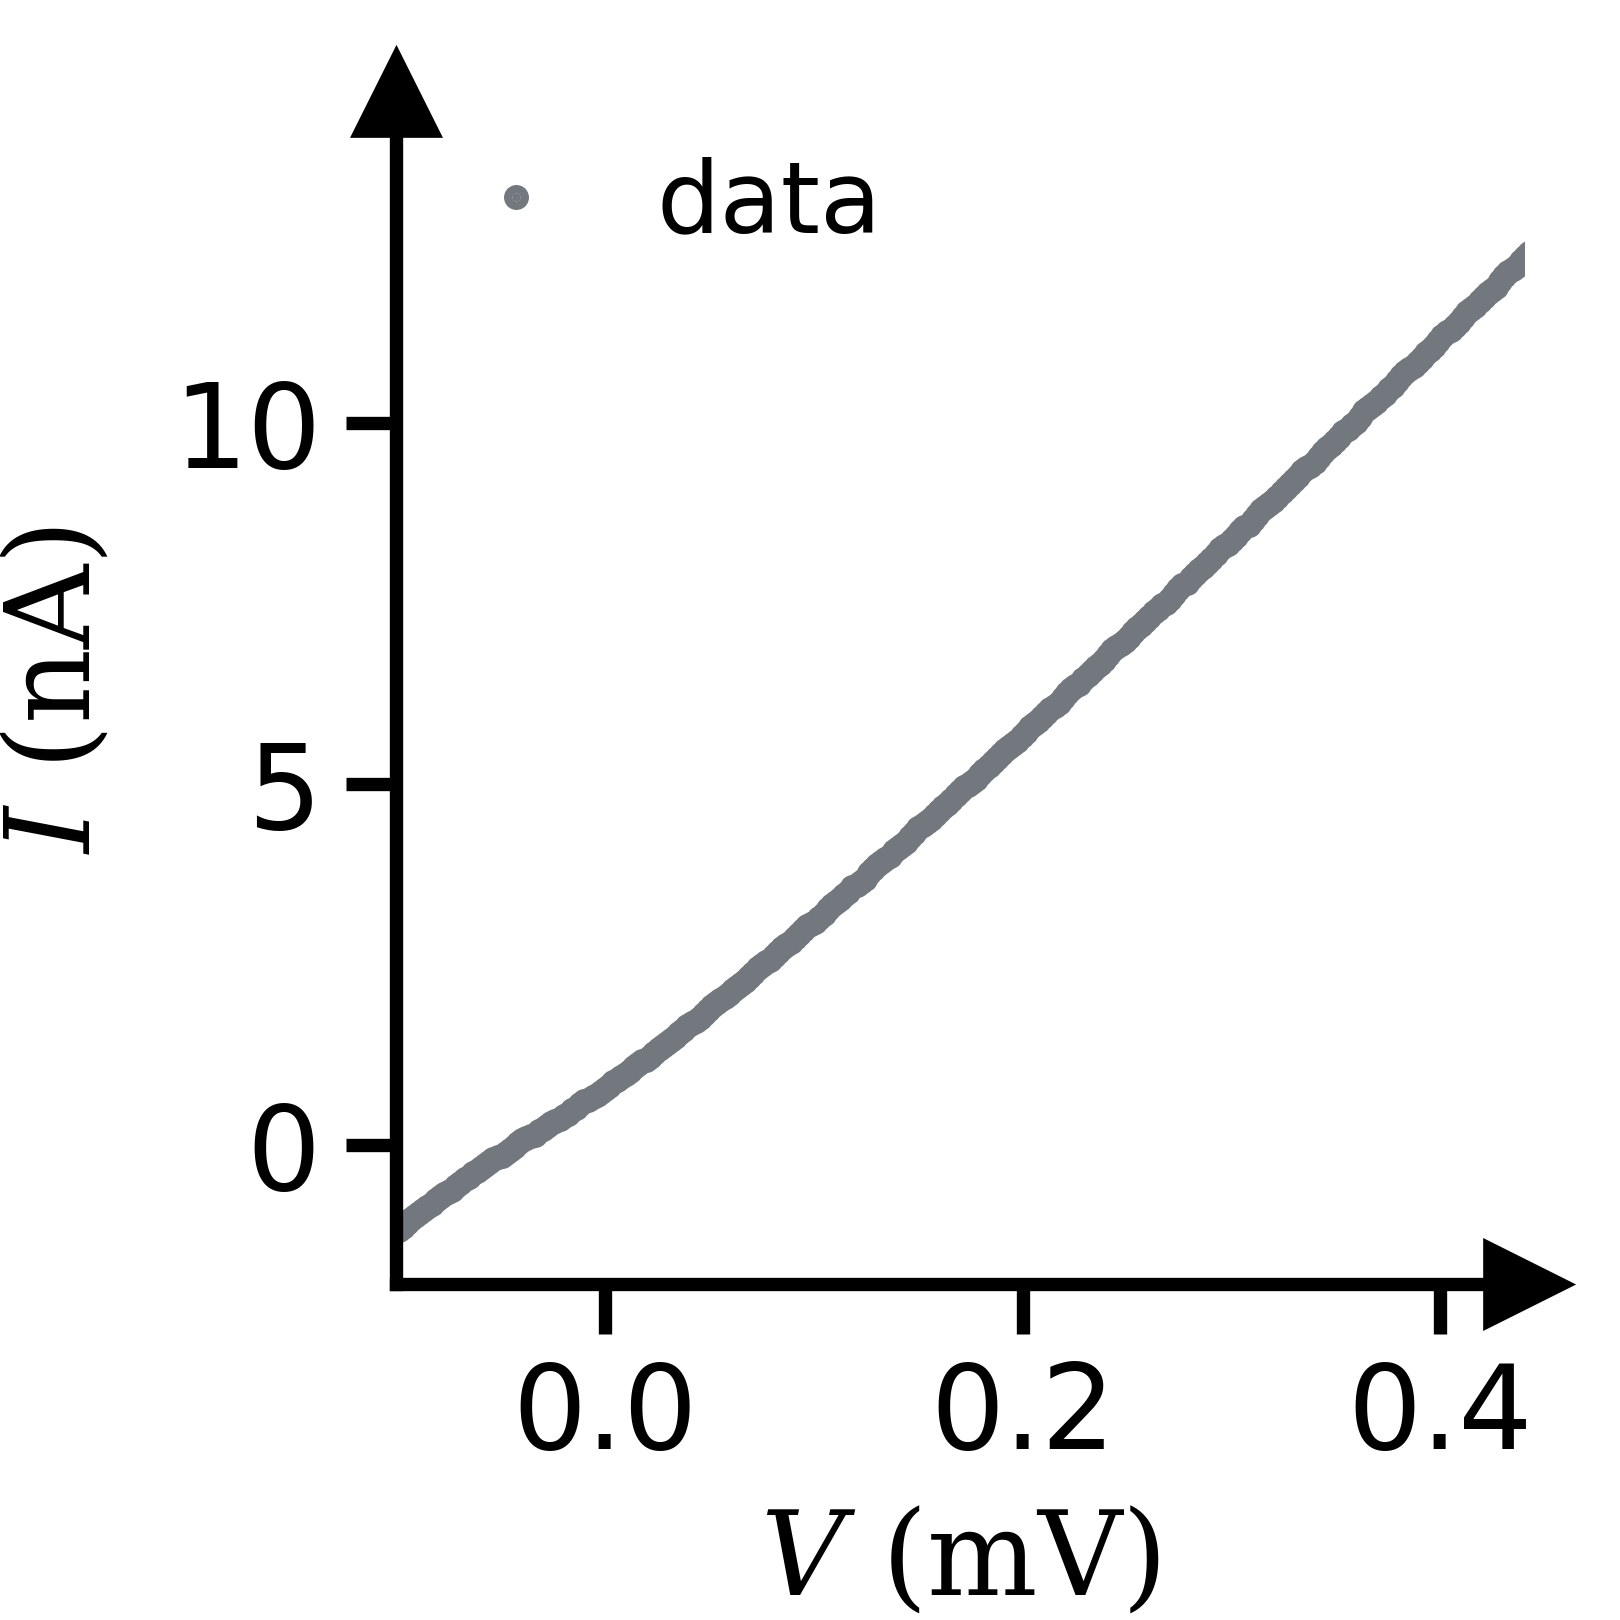

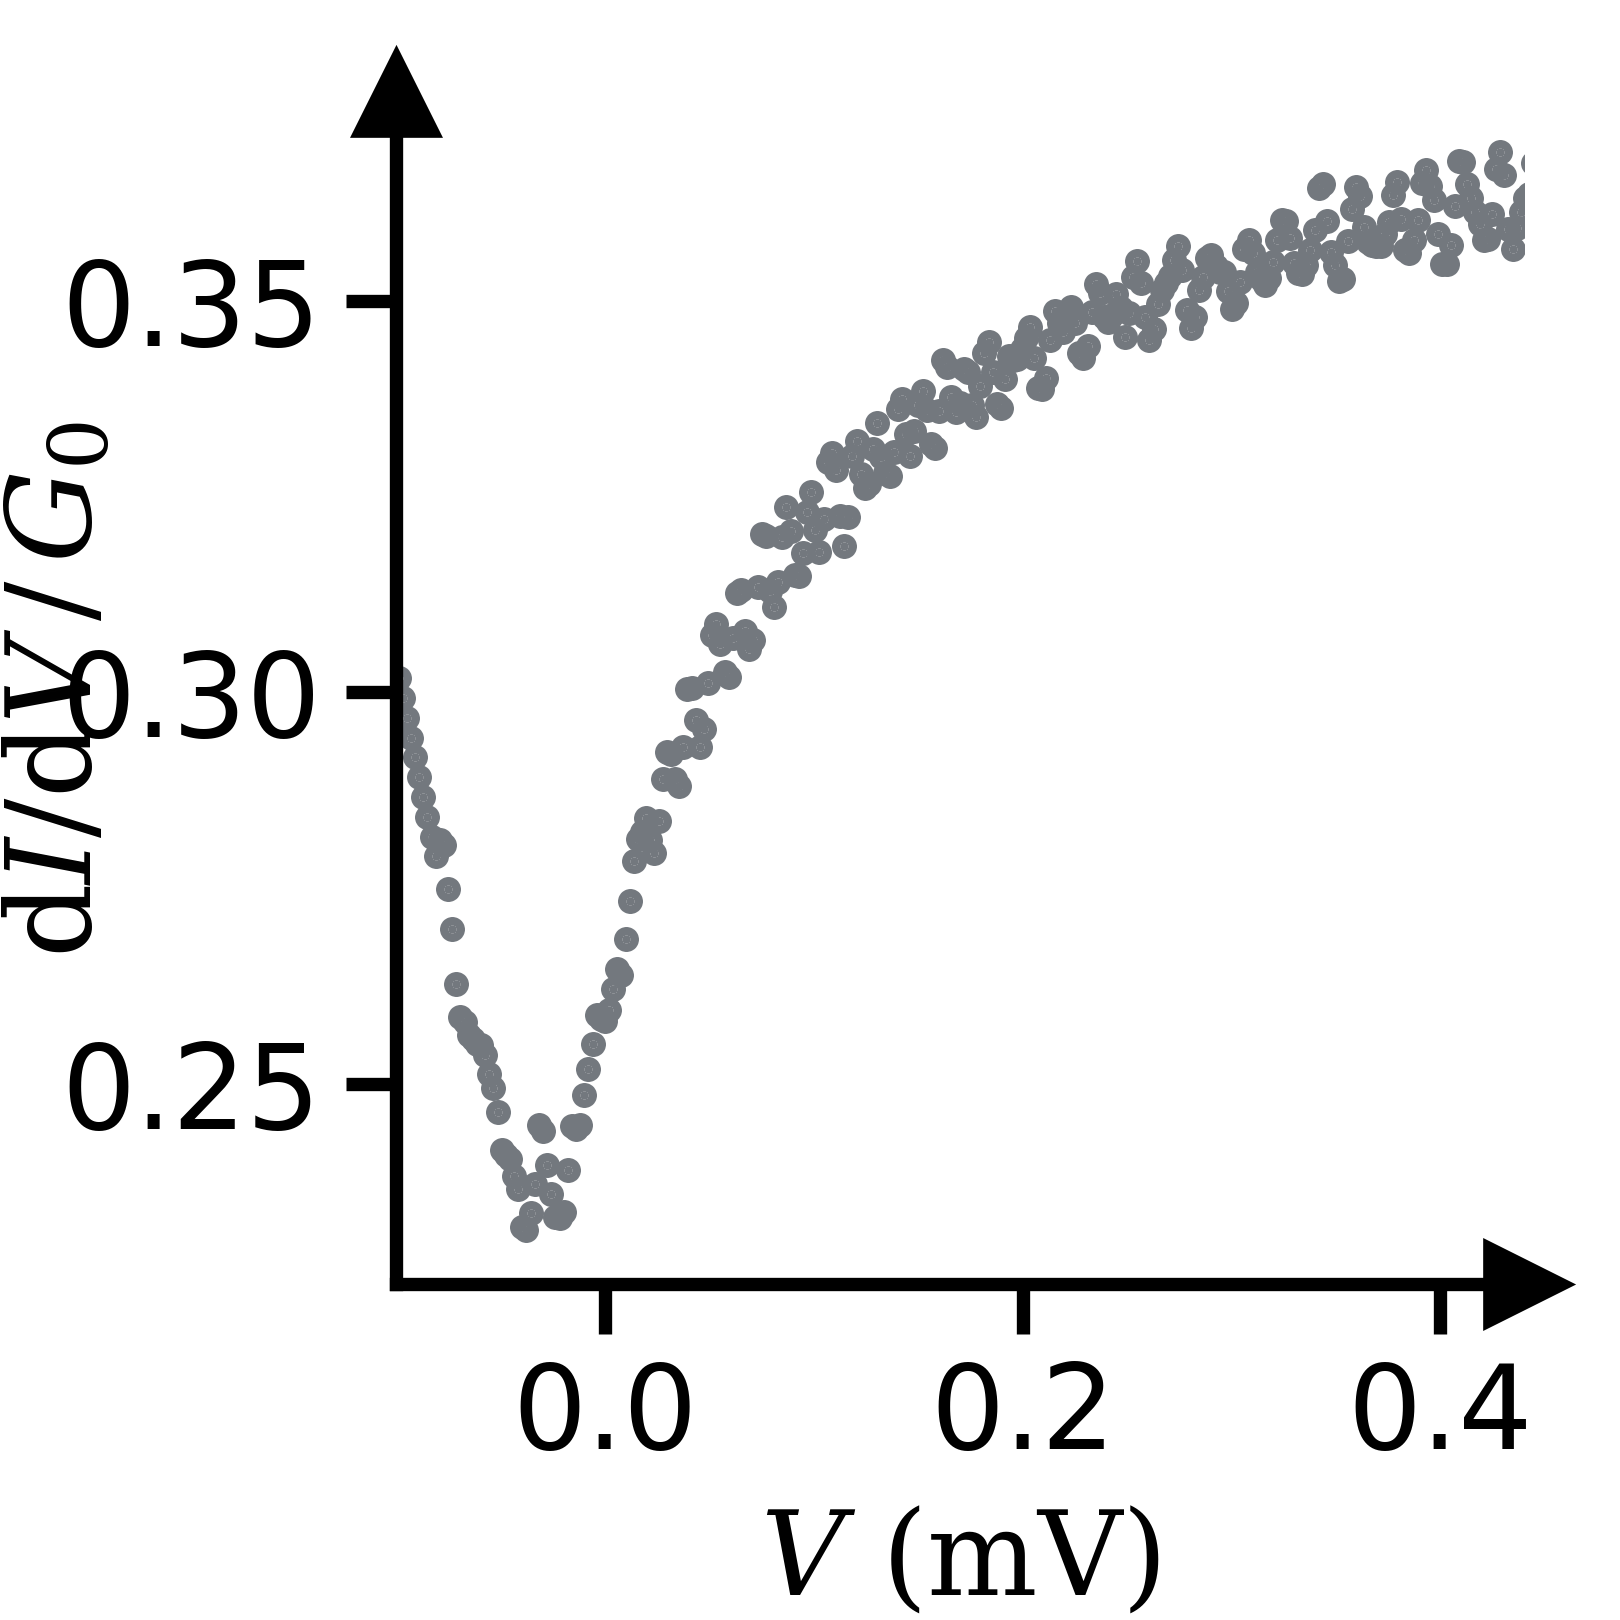

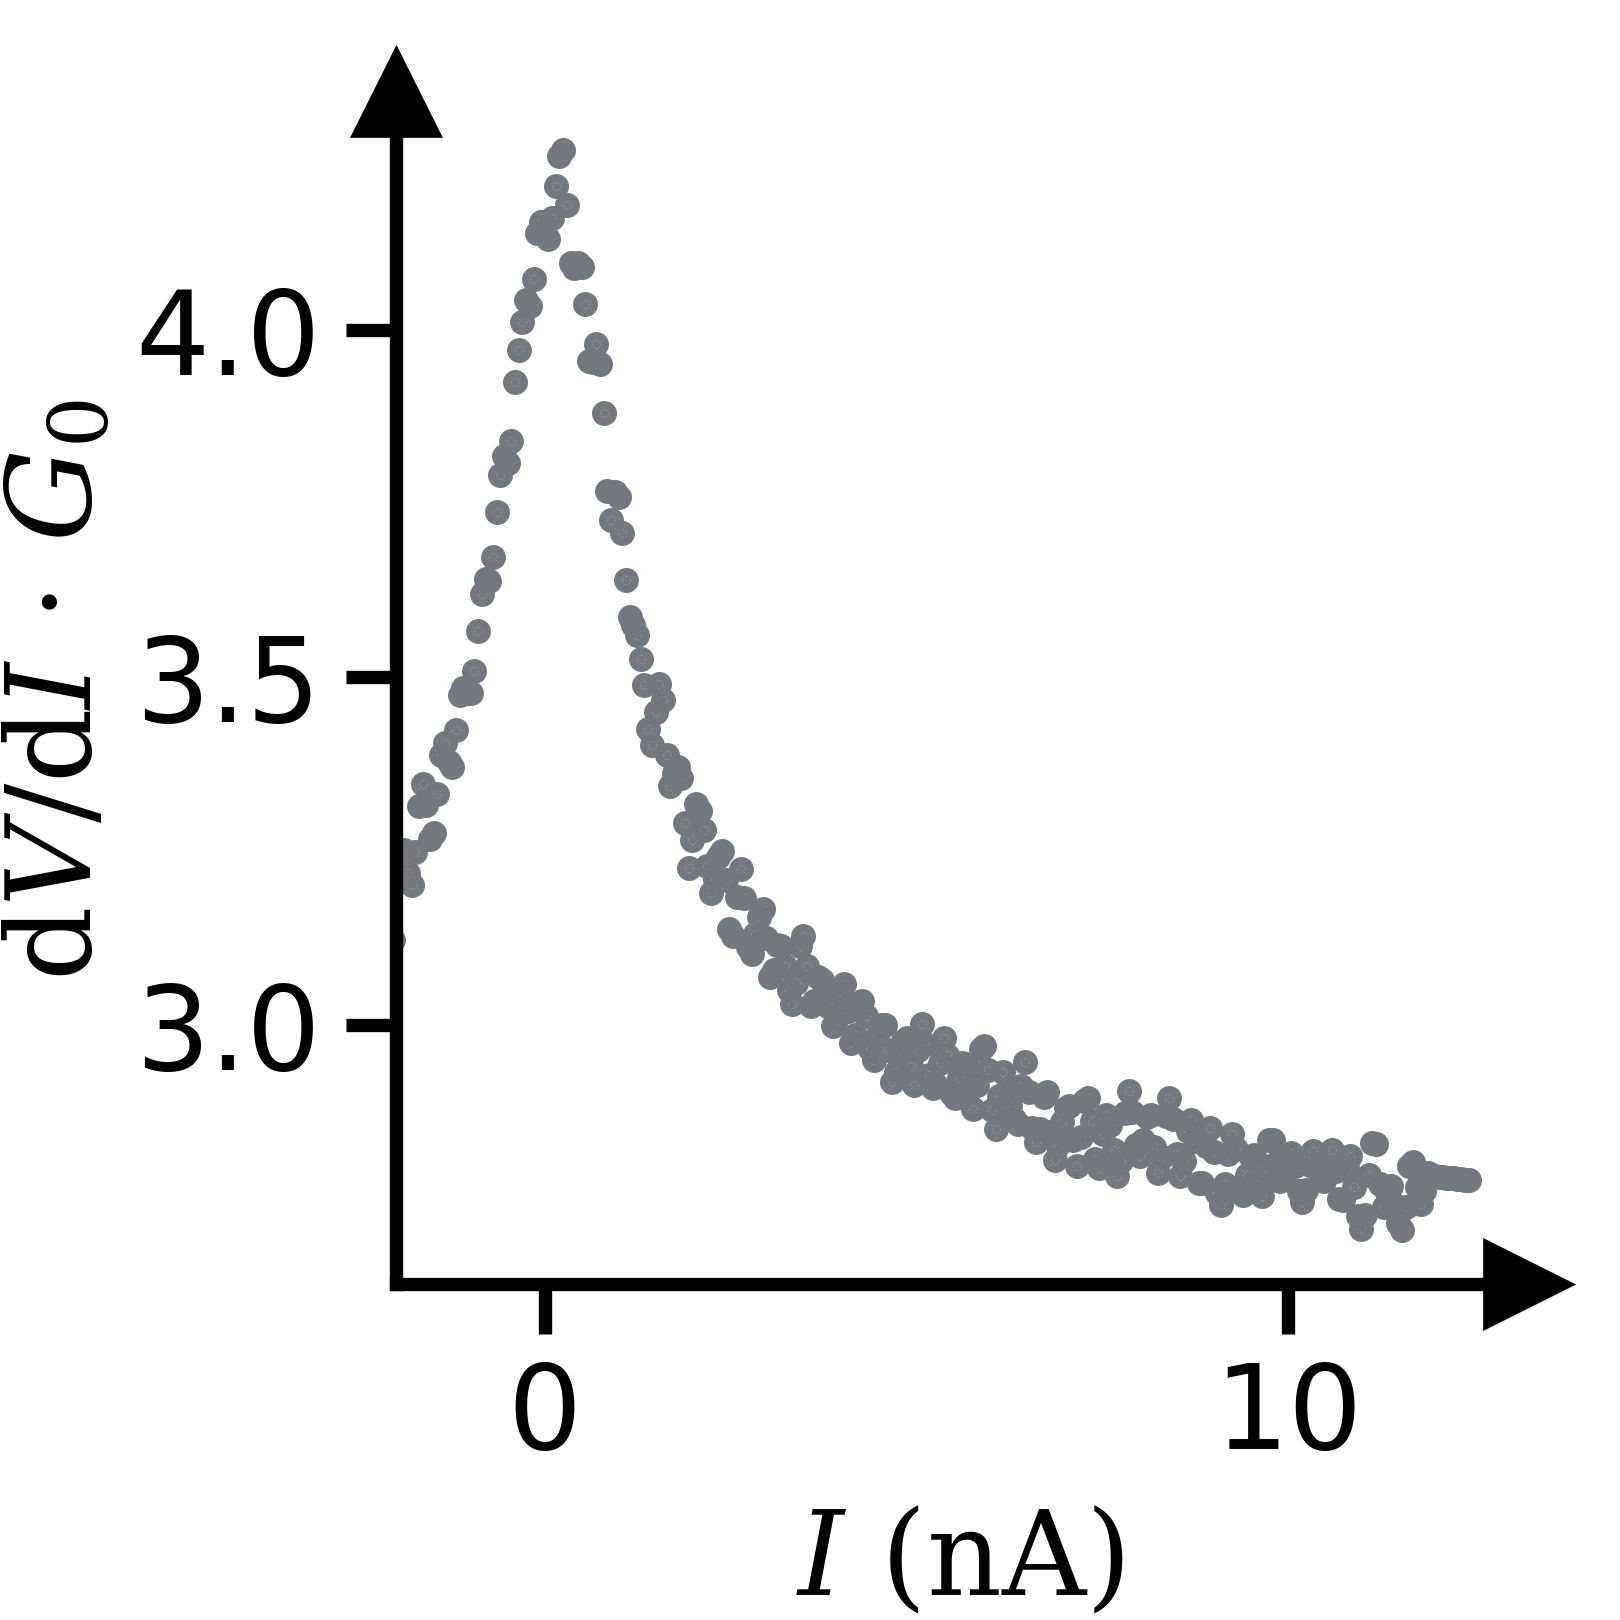

In [ ]:
# plot single-iv dcb

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Vbias * Delta_meV,
    Iexp * Delta_meV * GN_G0 * sc.G0_muS,
    ".",
    color=sc.seegrau100,
    ms=1.0,
    label="data",
    zorder=-1,
)
# ax.set_yticks([0, 20, 40, 60])
# ax.set_ylim(None, 75)
# ax.set_xticks([0, 0.2, 0.4])
ax.set_xlim(-0.1, 0.44)

ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/dcb-single/iv",
    "$V\\ \\mathrm{(mV)}$",
    "$I\\ \\mathrm{(nA)}$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Vbias * Delta_meV,
    savgol_filter(dGexp, 20, 1) * GN_G0,
    ".",
    color=sc.seegrau100,
    ms=1.0,
)
ax.set_xticks([0, 0.2, 0.4])
ax.set_xlim(-0.1, 0.44)
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/dcb-single/didv",
    "$V\\ \\mathrm{(mV)}$",
    "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_0$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Vbias * Delta_meV * GN_G0 * sc.G0_muS,
    savgol_filter(dRexp, 20, 1) / GN_G0,
    ".",
    color=sc.seegrau100,
    ms=1.0,
)
ax.set_xlim(-2, None)
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/dcb-single/dvdi",
    "$I\\ \\mathrm{(nA)}$",
    "$\\mathrm{d}V/\\mathrm{d}I\\,\\cdot\\,G_0$",
)
plt.show()

In [15]:
# get data single-iv dcb-ssn
file = "/Users/oliver/Documents/measurement data/SSET/22 03 Scheer2/36/SC_map.tdms"
key = "2022-03-31 08:53:52 G-4.00mV"
nu_sample_Hz, amp, rref = 5000.0, (2000.0, 500.0), 102000.0
dt_sample_s = 0.00019999999999999998
nu_downsample_Hz = 437.0
dt_downsample_s = 1 / nu_downsample_Hz

sweep = (25_000, 75_000)

Vbias0_mV = np.linspace(-0.7, 0.7, 3501)

with TdmsFile.open(file) as f:
    sample_V = f[key]["Sample"].as_dataframe()
    reference_V = f[key]["Reference"].as_dataframe()
    sample_V = sample_V.values
    reference_V = reference_V.values

sample_V = sample_V[sweep[0] : sweep[1], 0]
reference_V = reference_V[sweep[0] : sweep[1], 0]
time_s = np.arange(len(sample_V)) * dt_sample_s

nu_time_s = np.arange(0, np.max(time_s), dt_downsample_s)
nu_sample_V = sc.bin_y_over_x(sample_V, time_s, nu_time_s)
nu_reference_V = sc.bin_y_over_x(reference_V, time_s, nu_time_s)

v_mV = nu_sample_V * 1e3 / amp[0] + 0.0245
i_nA = nu_reference_V * 1e9 / (amp[1] * rref) + 4.8
valid = np.logical_and(np.isfinite(v_mV), np.isfinite(i_nA))
i_nA, v_mV = upsample(i_nA[valid]), upsample(v_mV[valid])
I0_nA = sc.bin_y_over_x(i_nA, v_mV, Vbias0_mV)

GN_G0 = 0.32488566119922346
Iexp0 = I0_nA / (Delta_meV * GN_G0 * sc.G0_muS)
Ifit0 = Ifit0_nA / (Delta_meV * GN_G0 * sc.G0_muS)
Vbias0 = Vbias0_mV / Delta_meV

In [26]:
# fit single-iv dcb-ssn

from scipy.optimize import curve_fit

GN_G0 = 0.7694245093456741
T_K = 0.0
Delta_meV = 0.19
gamma_meV = 1e-9
sigmaV_mV = 0.001

valid = np.isfinite(I0_nA)
v = Vbias0_mV[valid]
i = I0_nA[valid]

# valid = np.logical_and(v < 0.45, v > -0.45)
# v = v[valid]
# i = i[valid]


from superconductivity.models.basics.noise import evaluate_with_voltage_noise
from superconductivity.models.bcs.backend import E0_meV
from superconductivity.models.bcs.backend.np import convolution_np
from superconductivity.utilities.constants import G0_muS


def sntb(V_mV, Delta_meV, T_K, GN_G0):
    V_mV = np.asarray(V_mV, dtype=float)

    def current(V):
        return (
            convolution_np(
                V,
                E0_meV,
                T_K,
                T_K,
                0.0,  # normal electrode
                Delta_meV,  # superconducting electrode
                0.0,
                1e-6,
            )
            * GN_G0
            * G0_muS
        )

    if sigmaV_mV > 0:
        return evaluate_with_voltage_noise(
            V_mV,
            current,
            sigmaV_mV,
            order=64,
        )
    else:
        return current(V_mV)


popt, pcov = curve_fit(
    sntb,
    v,
    i,
    p0=(0.205, 0.1, 0.37960010969565455),
    bounds=((0.18, 0.001, 0.2), (0.23, 0.5, 0.5)),
    maxfev=10_000,
)
Ifit0_nA = sntb(Vbias0_mV, *popt)
Delta_meV, T_K, GN_G0 = popt
Iexp0 = I0_nA / (Delta_meV * GN_G0 * sc.G0_muS)
Ifit0 = Ifit0_nA / (Delta_meV * GN_G0 * sc.G0_muS)
Vbias0 = Vbias0_mV / Delta_meV

# Vbias = np.linspace(-0.6, 3.4, 401)
# Iexp = sc.bin_y_over_x(upsample(Iexp0), upsample(Vbias0), Vbias)
# Vexp = sc.bin_y_over_x(upsample(Vbias0), upsample(Iexp0), Vbias)
# dGexp = np.gradient(Iexp, Vbias, axis=-1)
# dRexp = np.gradient(Vexp, Vbias, axis=-1)


# Ifit = sc.bin_y_over_x(upsample(Ifit0), upsample(Vbias0), Vbias)
# Vfit = sc.bin_y_over_x(upsample(Vbias0), upsample(Ifit0), Vbias)
# dGfit = np.gradient(Ifit, Vbias, axis=-1)
# dRfit = np.gradient(Vfit, Vbias, axis=-1)

# dGexp = savgol_filter(dGexp, 10, 1)
# dRexp = savgol_filter(dRexp, 10, 1)
# dGfit = savgol_filter(dGfit, 10, 1)
# dRfit = savgol_filter(dRfit, 10, 1)

# Vbias = Vbias[:-10]
# Iexp = Iexp[:-10]
# Vexp = Vexp[:-10]
# dGexp = dGexp[:-10]
# dRexp = dRexp[:-10]
# Ifit = Ifit[:-10]
# Vfit = Vfit[:-10]
# dGfit = dGfit[:-10]
# dRfit = dRfit[:-10]
Delta_meV, T_K, GN_G0

(np.float64(0.2056219754008236),
 np.float64(0.20823510924338692),
 np.float64(0.34607964651617795))

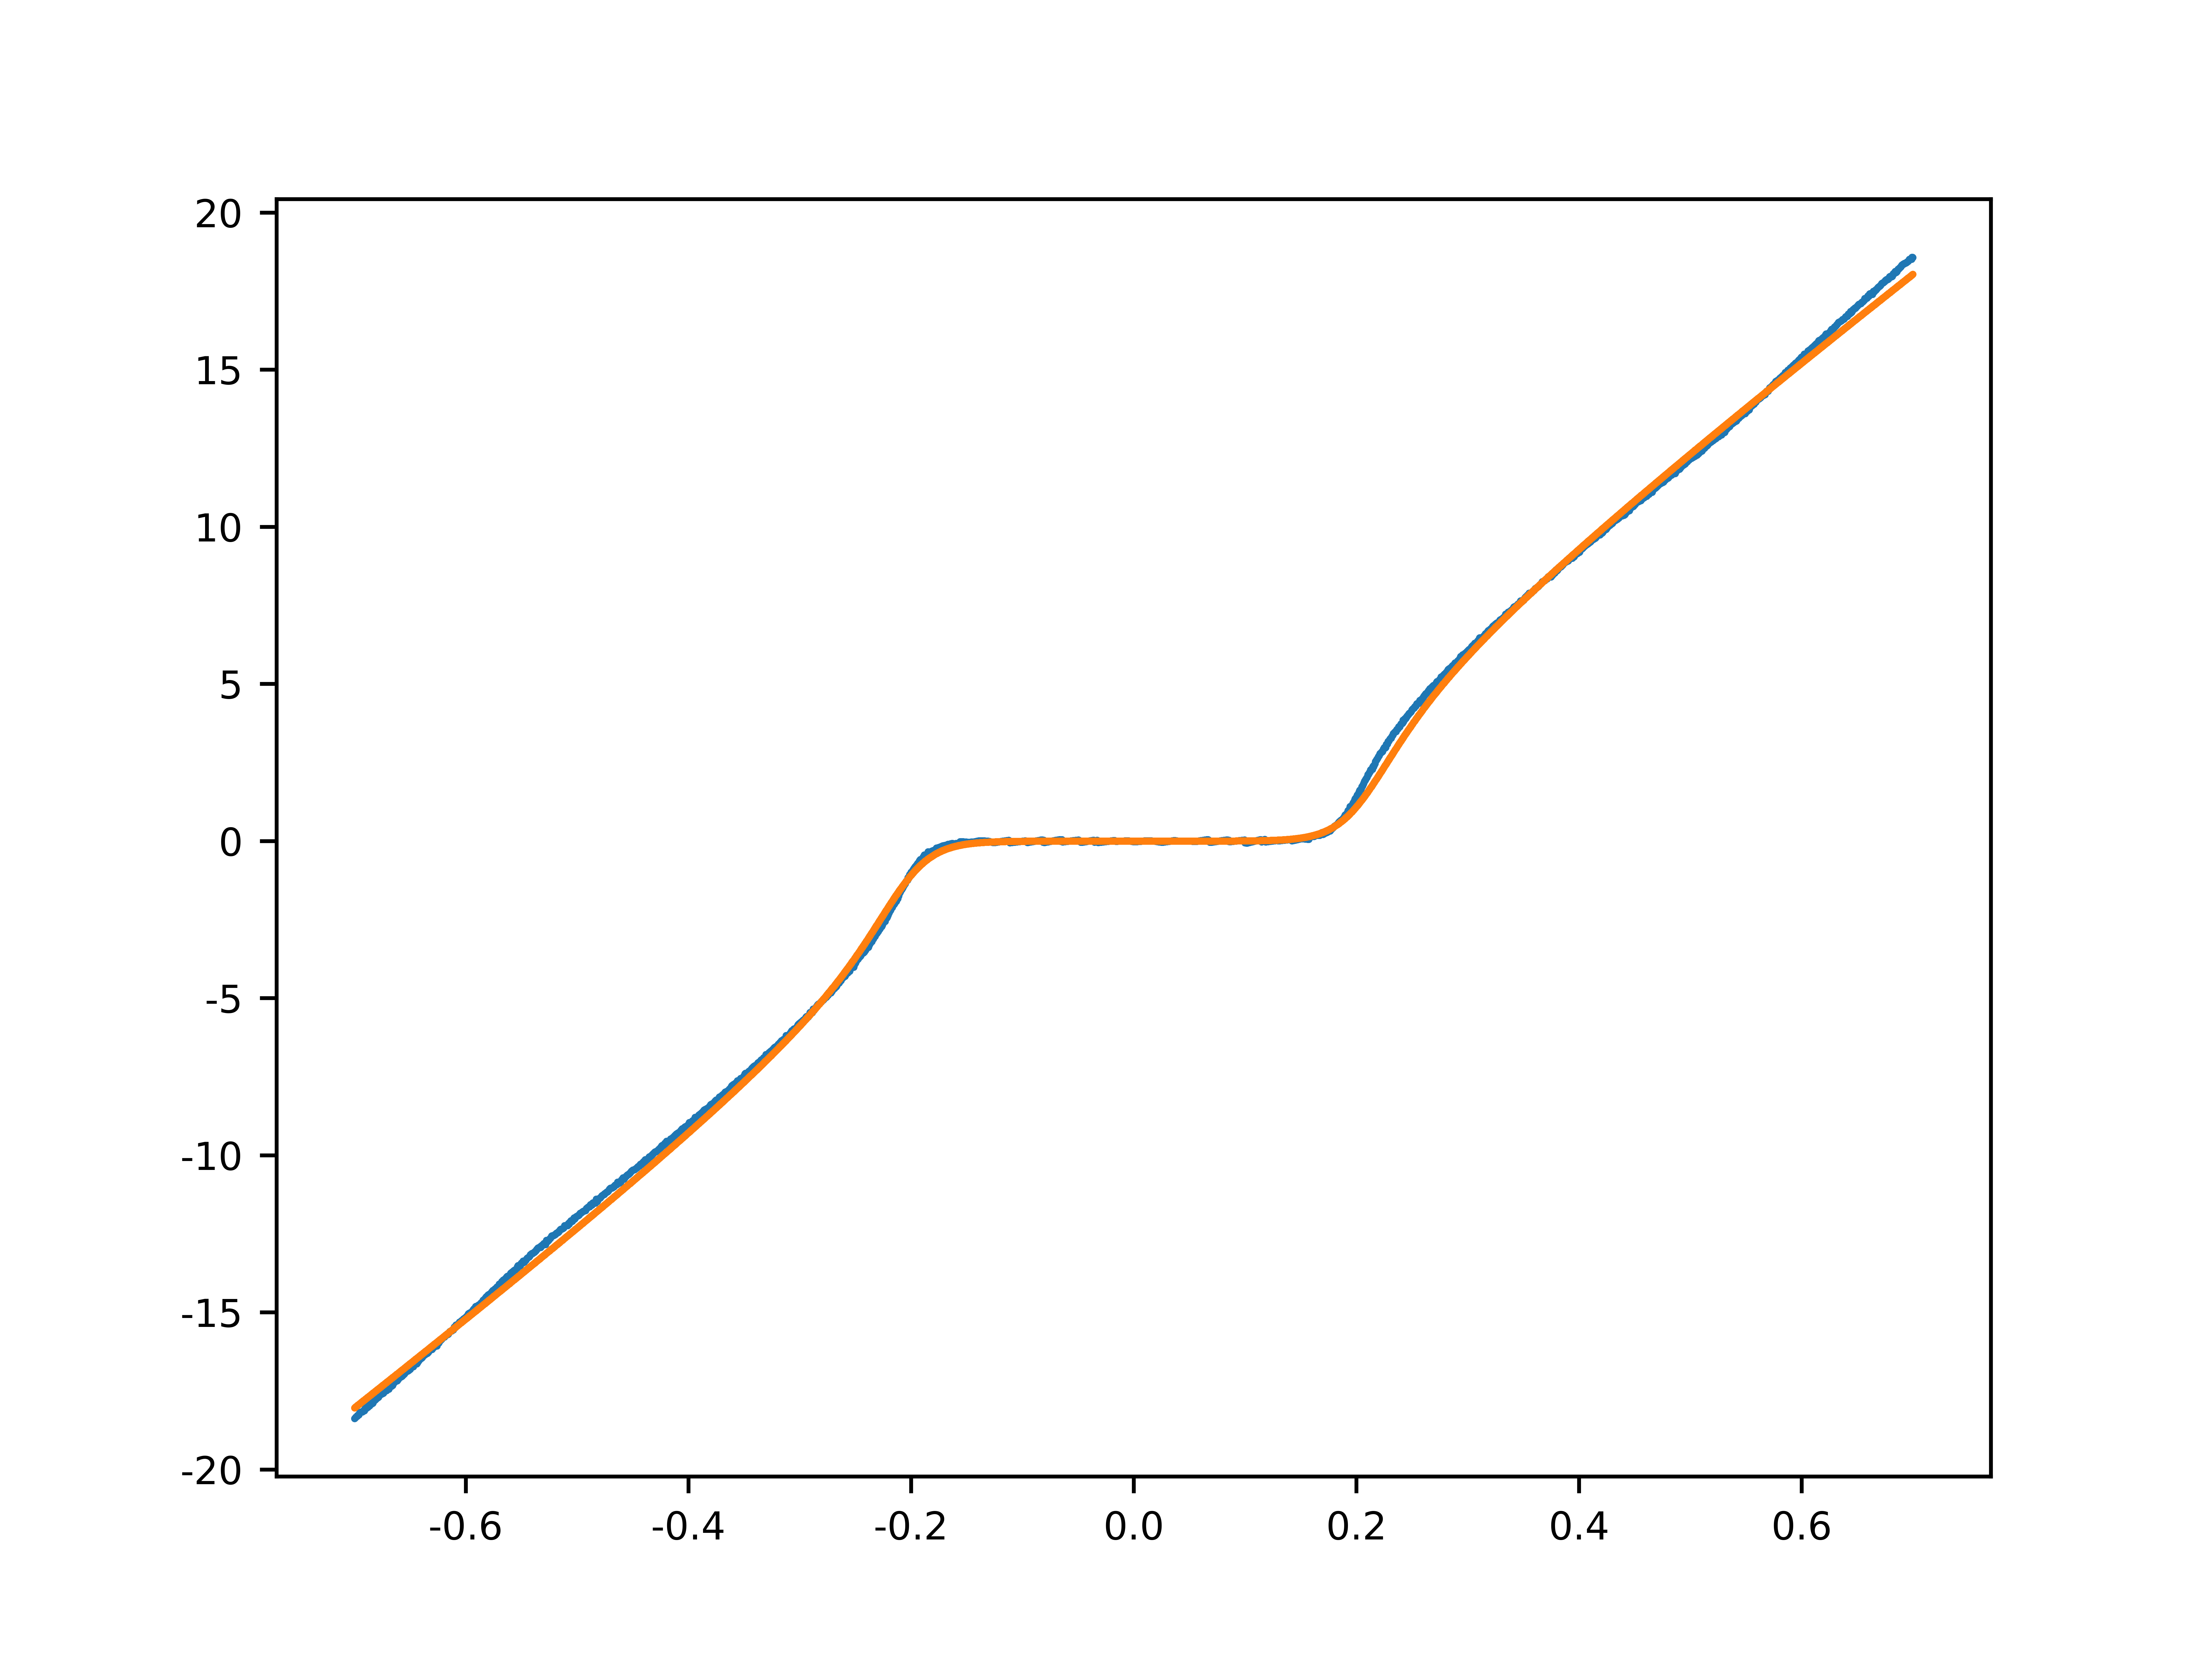

In [28]:
plt.plot(v, i, ".")
plt.plot(v, sntb(v, *popt), ".")

In [27]:
1000 / (GN_G0 * sc.G0_muS), 1 / (34 * 1e-3 * sc.G0_muS)

(np.float64(37.293160287162195), np.float64(0.37960010969565455))

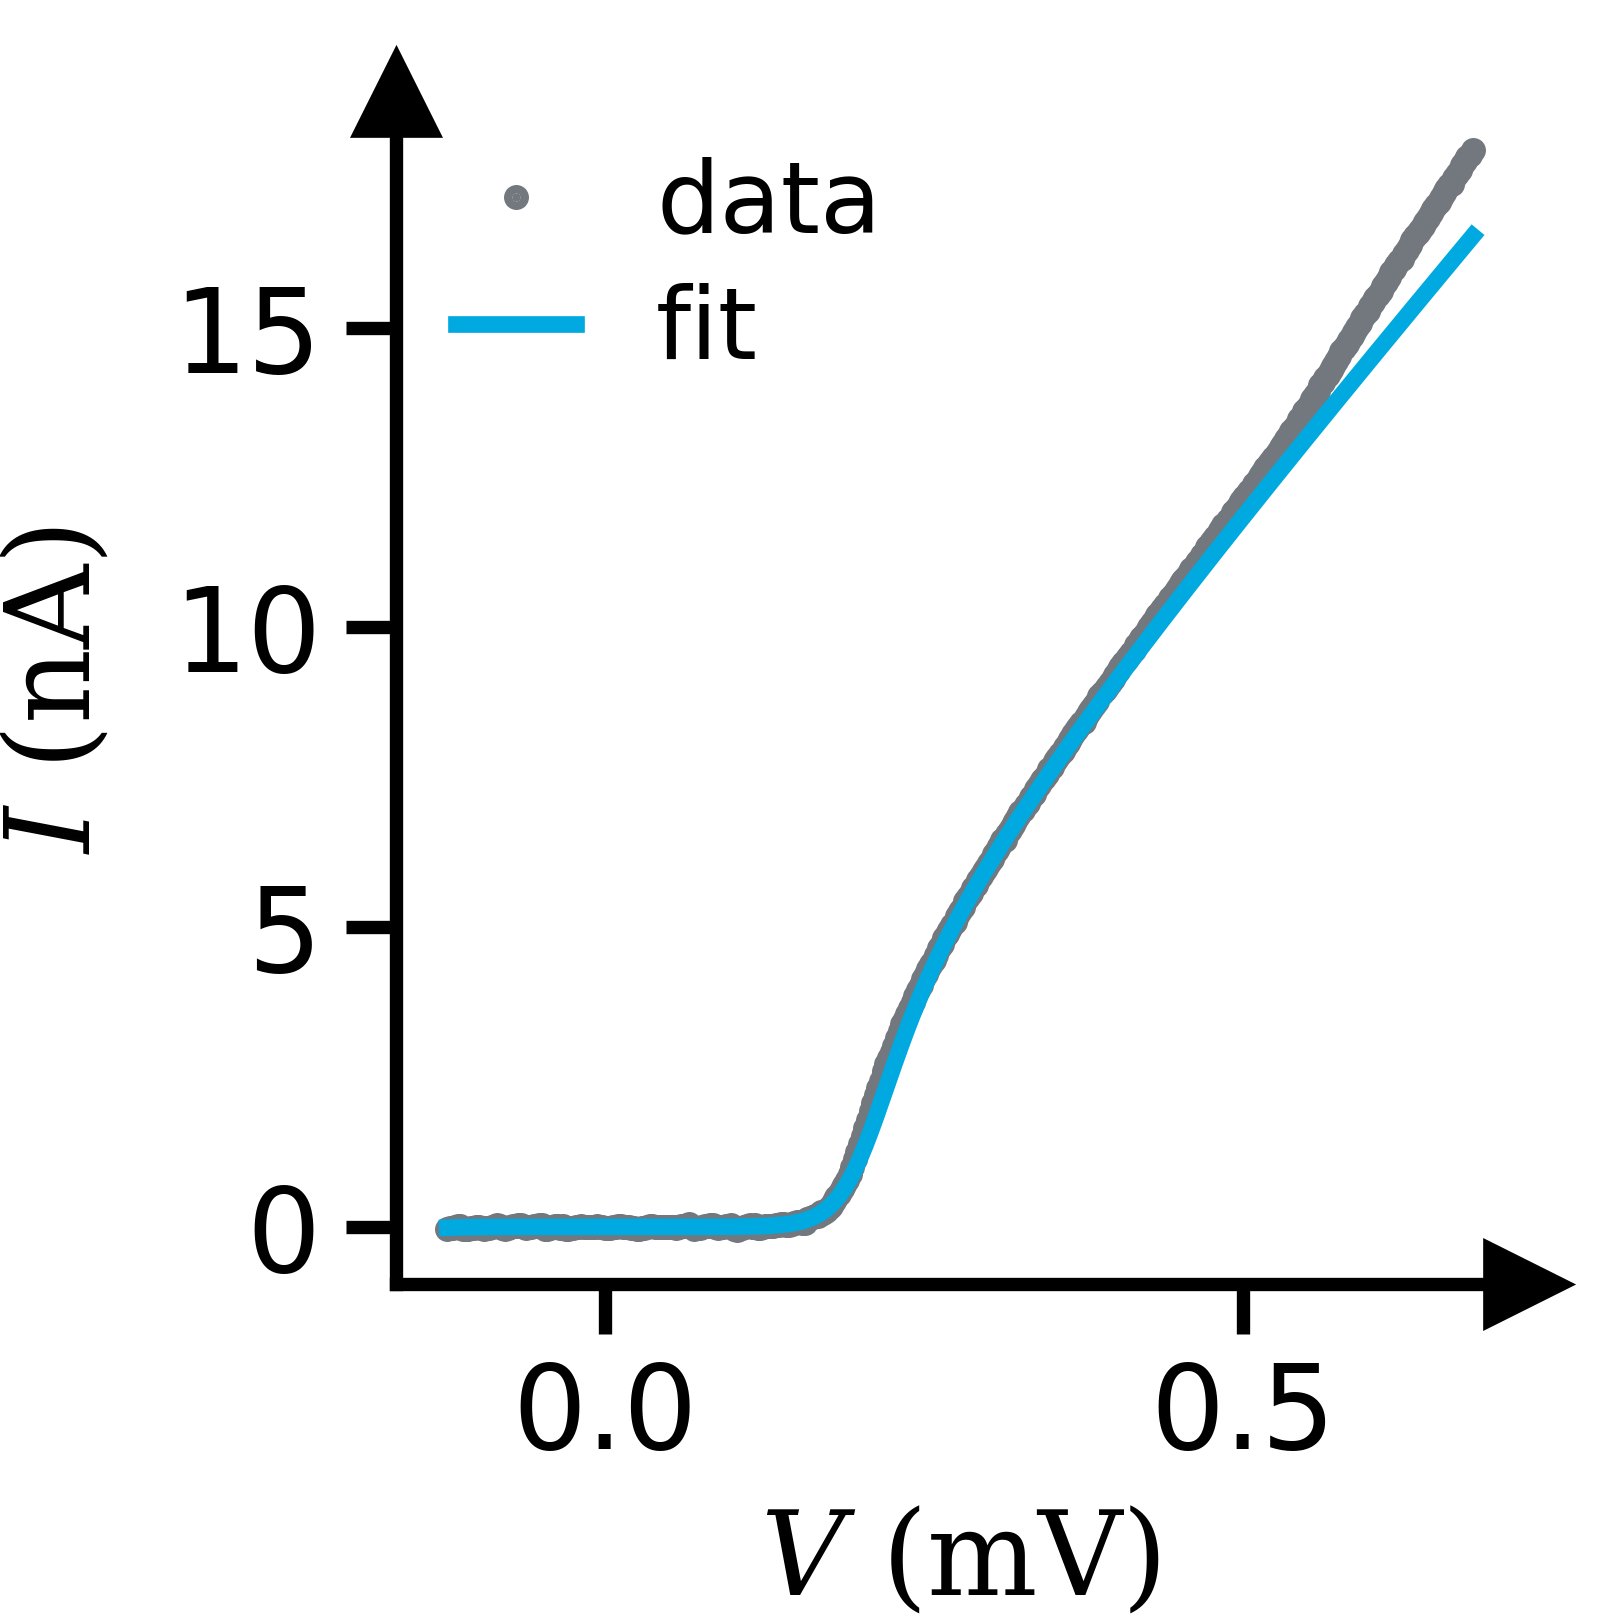

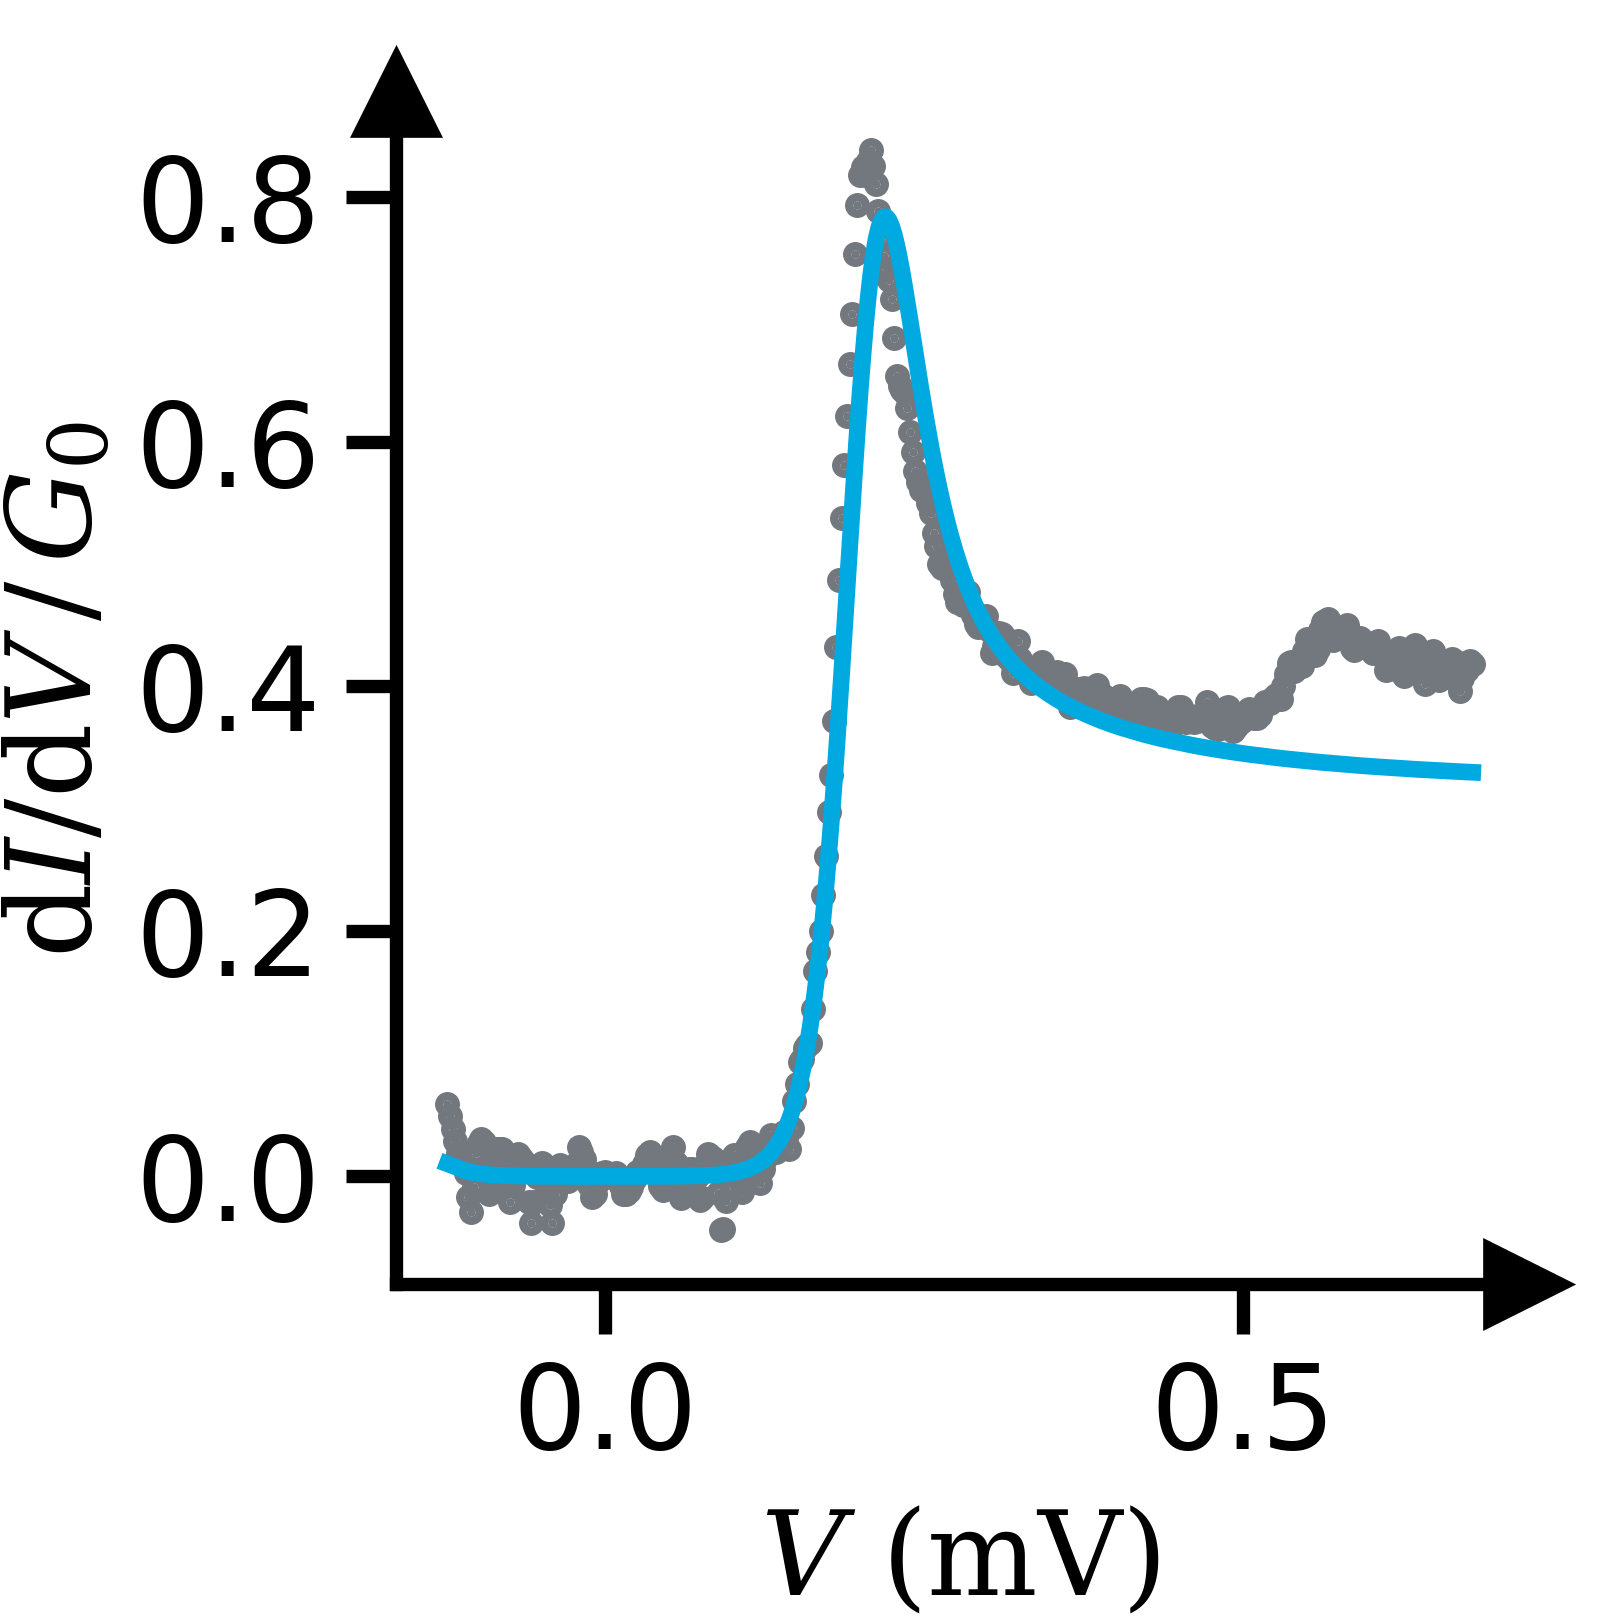

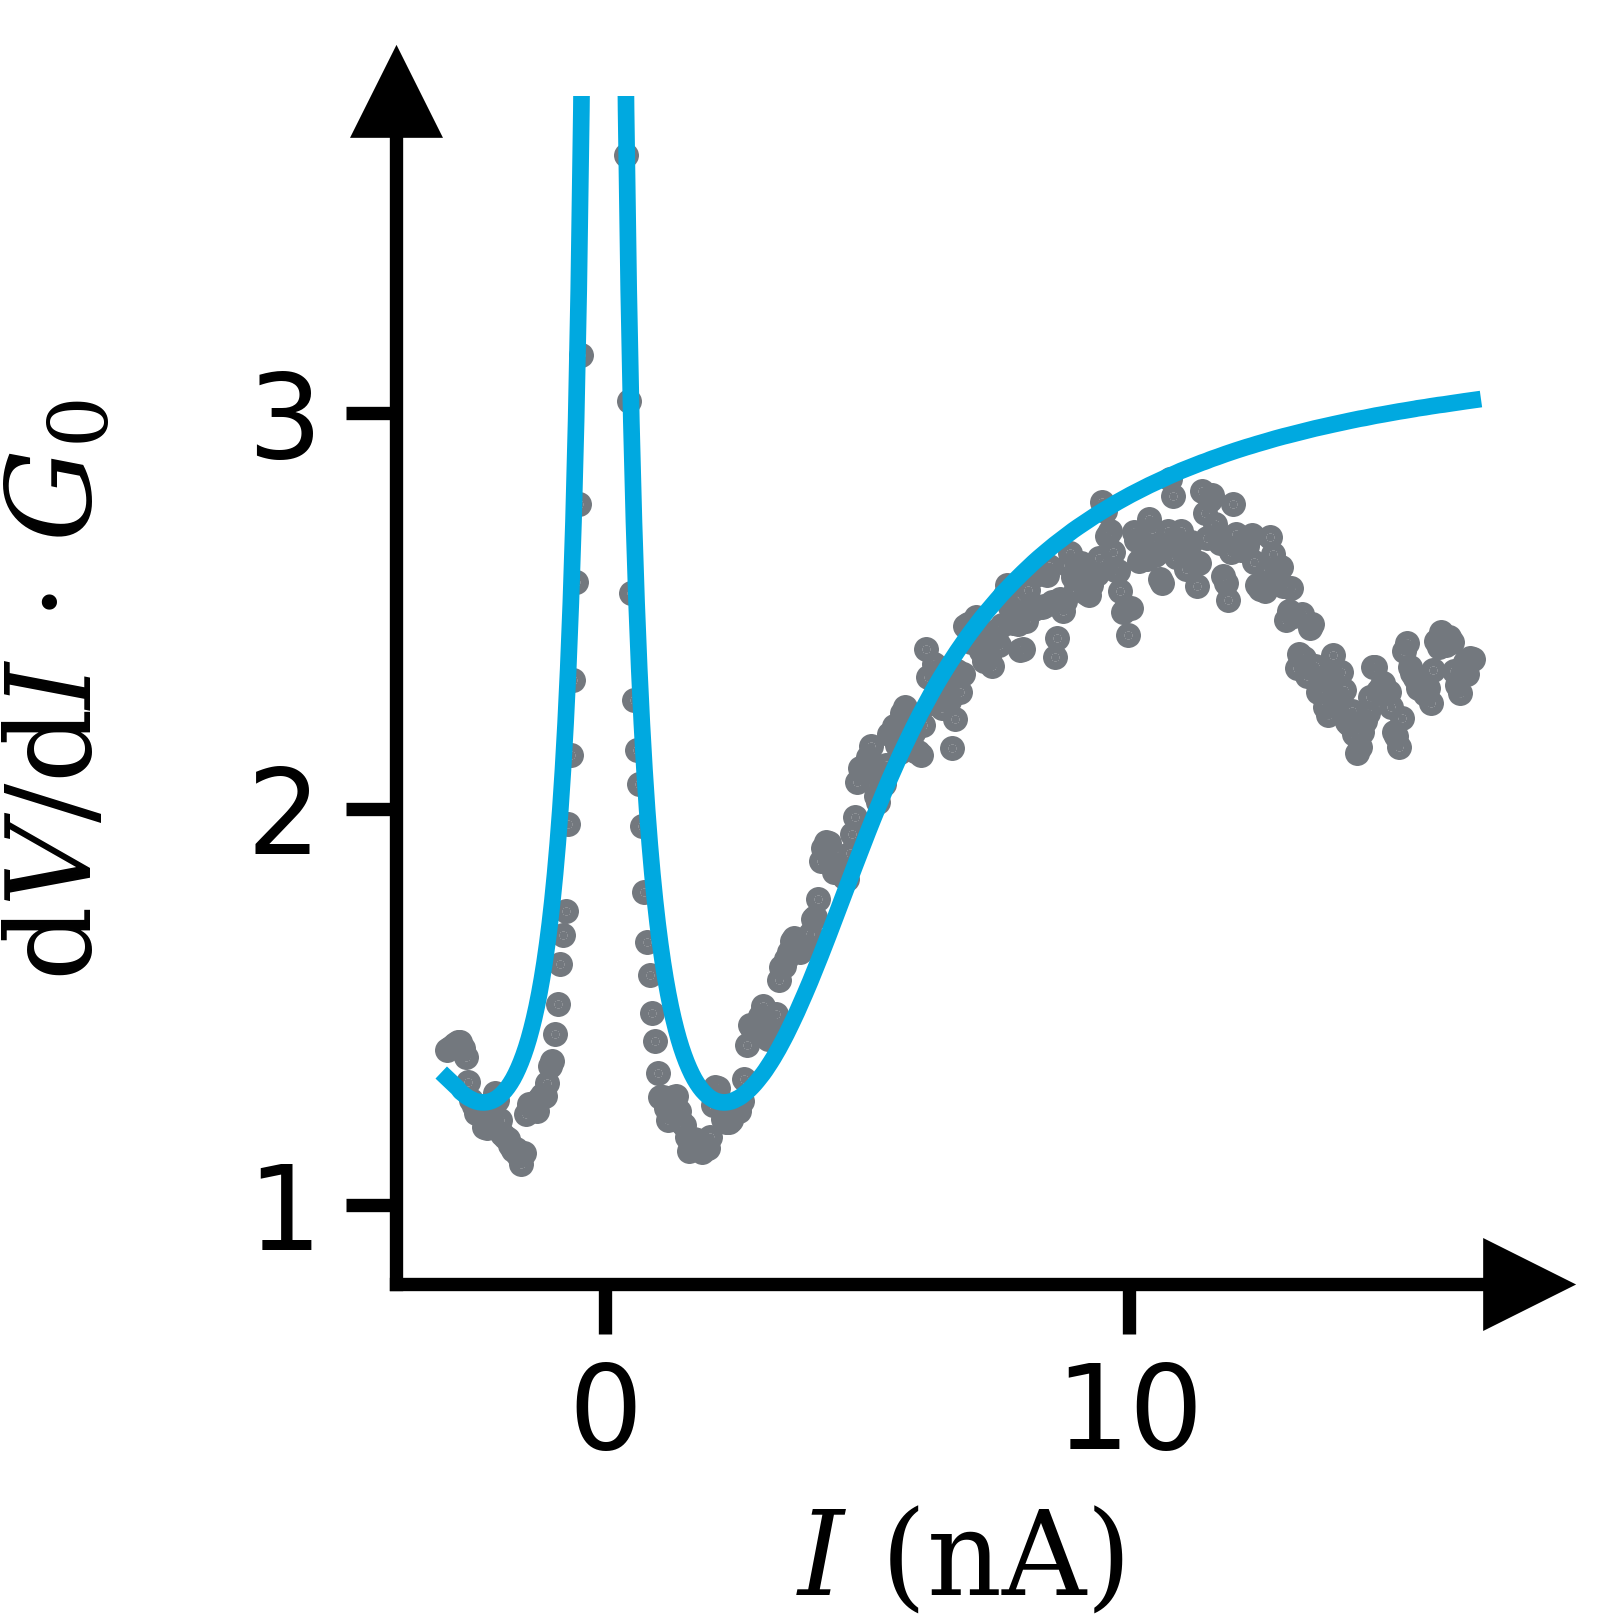

In [ ]:
# plot single-iv dcb-ssn

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Vbias * Delta_meV,
    Iexp * Delta_meV * GN_G0 * sc.G0_muS,
    ".",
    color=sc.seegrau100,
    ms=1.0,
    label="data",
    zorder=-1,
)
ax.plot(
    Vbias * Delta_meV,
    Ifit * Delta_meV * GN_G0 * sc.G0_muS,
    "-",
    color=sc.seeblau100,
    label="fit",
    zorder=0,
)
# ax.set_yticks([0, 20, 40, 60])
# ax.set_ylim(None, 75)
# ax.set_xticks([0, 0.2, 0.4])
# ax.set_xlim(-0.1, 0.49)

ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)
sc.theory_layout(
    fig,
    ax,
    f"dcb-ssn/tb-single/iv",
    "$V\\ \\mathrm{(mV)}$",
    "$I\\ \\mathrm{(nA)}$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(Vbias * Delta_meV, dGexp * GN_G0, ".", color=sc.seegrau100, ms=1.0)
ax.plot(Vbias * Delta_meV, dGfit * GN_G0, "-", color=sc.seeblau100)
# ax.set_xticks([0, 0.2, 0.4])
# ax.set_xlim(-0.1, 0.49)
sc.theory_layout(
    fig,
    ax,
    f"dcb-ssn/tb-single/didv",
    "$V\\ \\mathrm{(mV)}$",
    "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_0$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Vbias * Delta_meV * GN_G0 * sc.G0_muS,
    dRexp / GN_G0,
    ".",
    color=sc.seegrau100,
    ms=1.0,
)
ax.plot(Vbias * Delta_meV * GN_G0 * sc.G0_muS, dRfit / GN_G0, "-", color=sc.seeblau100)
ax.set_ylim(0.8, 3.8)
sc.theory_layout(
    fig,
    ax,
    f"dcb-ssn/tb-single/dvdi",
    "$I\\ \\mathrm{(nA)}$",
    "$\\mathrm{d}V/\\mathrm{d}I\\,\\cdot\\,G_0$",
)
plt.show()